# Калибровка моделей PD: сравнение методов с акцентом на сплайн-калибровку

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from IPython.display import display
from scipy.stats import norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from data.generate_data import generate_credit_data, get_same_year_calibration_test_split, portfolio_summary
from src.calibrators import get_all_calibrators
from src.metrics import (
    brier_score,
    bootstrap_ci,
    discrimination_metrics,
    fixed_bin_table,
    get_calibration_curve,
    summary_metrics,
)
from src.capital import IRBAssumptions, capital_volatility_summary, compare_845p_capital_by_method, calculate_845p_capital, compare_irb_capital_by_method, calculate_irb_capital
from src.portfolio import (
    MASTER_SCALE_RATINGS,
    assign_pd_master_scale_ratings,
    assign_master_scale_ratings,
    delta_logit_scenarios,
    compare_methods_by_historical_panel,
    compare_methods_by_rating_master_scale,
    historical_portfolio_panel,
    master_scale_pd_bound_capital,
    method_master_scale_distribution,
    method_portfolio_summary,
    rating_migration_matrix,
    portfolio_average_pd,
    rating_scale_capital,
    score_distribution_table,
    summarize_rating_scale,
    validate_common_rating_structure,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]
RANDOM_STATE = 42

print("Библиотеки и проектные модули загружены.")

Библиотеки и проектные модули загружены.


## 1. Постановка исследования и критерии сравнения

В рамках **Basel III / IRB-подхода** калибровка PD нужна не только для того, чтобы прогнозные вероятности совпадали с наблюдаемыми дефолтами по бинам риска, но и для того, чтобы итоговая оценка кредитного риска не искажала **резервы, RWA и требуемый капитал**. Поэтому в работе сравниваются не только графики калибровки, но и прикладной эффект от того, как каждый метод перераспределяет PD по шкале риска.

В исследовании сопоставляются шесть вариантов оценки PD на одной и той же базовой модели: **RF без калибровки**, **логит-калибровка**, **изотоническая регрессия**, **бета-калибровка**, **сплайн-калибровка** и **французский сплайн-калибровка**. Под сплайн-калибровкой понимается **монотонный гладкий сплайн**. Под **французским сплайном** понимается двухшаговая схема по мотивам подхода Banque de France / ICAS: сначала исходные PD калибруются логит-моделью, а затем логит-калиброванные PD дополнительно сглаживаются сплайном.

**Цель исследования** — определить, какой способ калибровки даёт наиболее обоснованное распределение PD по всей шкале риска и как это отражается на прикладном результате: величине **Reserves**, **RWA**, **требуемого капитала при H1 = 8%** и **экономии капитала относительно сырых PD**.

**Критерии сравнения** разделены на две группы:
- **статистические**: Brier Score, Log-Loss, ECE, HL p-value, а также визуальная согласованность PD с фактическими дефолтами по reliability-diagram и по фиксированным бинам `[0.0–0.1], …, [0.9–1.0]`;
- **прикладные**: итоговые **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%**, **экономия капитала относительно сырых PD** и уровень **H1**, если сохранить капитал, достаточный для сырых PD.

Для сопоставимости прикладной части принимаются фиксированные допущения: **EAD = 1 000 000** для каждого наблюдения и **LGD = 40%**. Поэтому различия в итоговом капитале интерпретируются как эффект именно от выбора метода калибровки PD.

## 2. Данные: синтетический кредитный портфель

In [2]:
PORTFOLIO_SCENARIO = "normal"
df = generate_credit_data(
    n_samples=40000,
    random_state=RANDOM_STATE,
    portfolio=PORTFOLIO_SCENARIO,
)

print(f"Сценарий портфеля: {PORTFOLIO_SCENARIO}")
print(f"Датасет: {df.shape[0]:,} строк | {df.shape[1]} столбцов")
print(f"Общая доля дефолтов: {df['default'].mean():.2%}")
print(f"Средняя истинная PD в синтетике: {df['true_pd'].mean():.2%}\n")

true_pd_stats = df["true_pd"].describe(percentiles=[0.50, 0.90, 0.95, 0.99])[["min", "50%", "90%", "95%", "99%", "max"]]
print("Распределение истинной PD в портфеле:")
print(true_pd_stats.map(lambda x: f"{x:.2%}"))

segment_stats = (
    df.groupby("risk_segment")
      .agg(наблюдений=("default", "count"), доля_дефолтов=("default", "mean"), средняя_true_pd=("true_pd", "mean"))
)
segment_map = {0: "0 = prime", 1: "1 = standard", 2: "2 = subprime", 3: "3 = distressed"}
segment_stats.index = segment_stats.index.map(segment_map)
segment_stats["доля_дефолтов"] = segment_stats["доля_дефолтов"].map("{:.2%}".format)
segment_stats["средняя_true_pd"] = segment_stats["средняя_true_pd"].map("{:.2%}".format)
print("\nРиск-сегменты синтетического портфеля:")
print(segment_stats)

by_year = df.groupby("origination_year")["default"].agg(всего="count", дефолтов="sum", доля="mean")
by_year["доля"] = by_year["доля"].map("{:.2%}".format)
print("\nДефолты по годам выдачи:")
print(by_year)

display(df.drop(columns=["default", "origination_year", "risk_segment", "true_pd"]).describe().round(2))

Сценарий портфеля: normal
Датасет: 40,000 строк | 13 столбцов
Общая доля дефолтов: 2.53%
Средняя истинная PD в синтетике: 2.51%

Распределение истинной PD в портфеле:
min     0.04%
50%     0.19%
90%     4.24%
95%    10.90%
99%    57.40%
max    94.20%
Name: true_pd, dtype: str

Риск-сегменты синтетического портфеля:
                наблюдений доля_дефолтов средняя_true_pd
risk_segment                                            
0 = prime            20705         0.14%           0.12%
1 = standard         13327         0.45%           0.52%
2 = subprime          4783         7.65%           7.16%
3 = distressed        1185        47.17%          47.77%

Дефолты по годам выдачи:
                  всего  дефолтов   доля
origination_year                        
2019               5513       134  2.43%
2020               5576       158  2.83%
2021               7219       177  2.45%
2022               7275       161  2.21%
2023               8045       202  2.51%
2024               6372     

,credit_score,ltv,dti,employment_years,loan_amount,loan_term,num_delinquencies,loan_purpose
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,690.07,0.36,0.24,7.23,186.68,41.95,0.34,0.92
std,100.23,0.21,0.17,4.28,171.93,21.25,0.71,0.88
min,300.00,0.05,0.03,0.00,11.20,12.00,0.00,0.00
25%,635.00,0.19,0.11,4.00,95.30,24.00,0.00,0.00
50%,712.00,0.31,0.18,7.10,140.00,36.00,0.00,1.00
75%,763.00,0.49,0.33,10.20,216.70,48.00,0.00,2.00
max,850.00,0.95,0.87,25.90,4728.90,120.00,8.00,2.00


### Историческая структура портфеля по рейтингам

Здесь портфель не сводится к одной средней PD. Мы восстанавливаем его как `год выдачи × рейтинг`: количество наблюдений, доля рейтинга в портфеле, средняя PD, фактическая доля дефолтов и ожидаемое число дефолтов. Одна агрегированная PD выводится только как контрольный итог.


In [3]:
historical_panel_true = historical_portfolio_panel(df, pd_col="true_pd")
portfolio_avg_true_pd = portfolio_average_pd(df, pd_col="true_pd")

print(f"Агрегированная PD портфеля: {portfolio_avg_true_pd:.2%}")
print("Эта величина нужна только как итог; анализ ниже сохраняет структуру год × рейтинг.")

portfolio_view_cols = [
    "origination_year",
    "rating",
    "n_obs",
    "portfolio_count_share",
    "avg_pd",
    "observed_default_rate",
    "expected_defaults",
    "defaults",
    "calibration_ratio",
]
display(
    historical_panel_true[portfolio_view_cols]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "avg_pd": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)


Агрегированная PD портфеля: 2.51%
Эта величина нужна только как итог; анализ ниже сохраняет структуру год × рейтинг.


,origination_year,rating,n_obs,portfolio_count_share,avg_pd,observed_default_rate,expected_defaults,defaults,calibration_ratio
0,2019,A,2833,51.4%,0.11%,0.14%,3.17,4,1.26
1,2019,B,1834,33.3%,0.49%,0.49%,9.00,9,1.00
2,2019,C,686,12.4%,6.95%,7.00%,47.66,48,1.01
3,2019,D,160,2.9%,47.18%,45.62%,75.49,73,0.97
4,2020,A,2914,52.3%,0.15%,0.14%,4.50,4,0.89
5,2020,B,1857,33.3%,0.67%,0.48%,12.48,9,0.72
6,2020,C,642,11.5%,8.92%,7.94%,57.24,51,0.89
7,2020,D,163,2.9%,54.29%,57.67%,88.50,94,1.06
8,2021,A,3703,51.3%,0.11%,0.16%,4.13,6,1.45
9,2021,B,2422,33.6%,0.50%,0.45%,12.00,11,0.92


### Проверка сценариев портфеля: normal vs stress

В проекте есть два режима генерации портфеля. Основной notebook дальше использует `normal`, потому что итоговое распределение должно быть похоже на рабочий кредитный портфель: основная масса заемщиков находится в низко- и среднерисковых рейтингах, а `E` остается небольшим хвостом. Сценарий `stress` сохраняется только как диагностическое сравнение, чтобы показать, как выглядит портфель при искусственно утяжеленной PD-шкале.

In [4]:
scenario_rows = []
for scenario in ["normal", "stress"]:
    scenario_df = generate_credit_data(n_samples=40_000, random_state=RANDOM_STATE, portfolio=scenario)
    summary = portfolio_summary(scenario_df)
    scenario_rows.append({
        "scenario": scenario,
        "n_obs": summary["n_obs"],
        "default_rate": summary["default_rate"],
        "avg_true_pd": summary["avg_true_pd"],
        "p95_true_pd": summary["p95_true_pd"],
        "max_true_pd": summary["max_true_pd"],
    })

scenario_table = pd.DataFrame(scenario_rows).set_index("scenario")
display(
    scenario_table.style.format({
        "default_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "p95_true_pd": "{:.2%}",
        "max_true_pd": "{:.2%}",
    })
)

print("Дальше в notebook используется normal-сценарий: основная масса портфеля должна идти слева направо от A/B к хвосту D/E.")

,n_obs,default_rate,avg_true_pd,p95_true_pd,max_true_pd
scenario,,,,,
normal,40000,2.53%,2.51%,10.90%,94.20%
stress,40000,13.66%,13.62%,82.49%,99.58%


Дальше в notebook используется normal-сценарий: основная масса портфеля должна идти слева направо от A/B к хвосту D/E.


## 3. Экспериментальный протокол и схема выборок

Финальная схема соответствует рекомендации ментора:
- **Train (2019-2023)** - обучение базовой модели score;
- **Calibration (2024)** - настройка калибраторов на score за 2024 год;
- **Test / RWA (2024)** - расчет качества, распределения по мастер-шкале и капитала на той же выборке 2024 года.

Калибровка и тест намеренно используют одни и те же наблюдения 2024 года. Это не независимая out-of-time валидация, а прикладной расчет капитала на фиксированном портфеле: разные методы калибровки сравниваются на одних и тех же заемщиках.

Мастер-шкала A1...E рассматривается как заданная шкала: рейтинг назначается по диапазону откалиброванной PD, а не по произвольной нарезке score.

In [5]:
X_train, X_calib, X_test, y_train, y_calib, y_test = get_same_year_calibration_test_split(df)

print("Mentor sample split:")
print(f"  Train       (2019-2023): {len(X_train):,} rows | defaults: {y_train.mean():.2%}")
print(f"  Calibration (2024):      {len(X_calib):,} rows | defaults: {y_calib.mean():.2%}")
print(f"  Test/RWA    (2024):      {len(X_test):,} rows | defaults: {y_test.mean():.2%}")
print(f"  Calibration and test are the same sample: {X_calib.index.equals(X_test.index)}")

Mentor sample split:
  Train       (2019-2023): 33,628 rows | defaults: 2.47%
  Calibration (2024):      6,372 rows | defaults: 2.84%
  Test/RWA    (2024):      6,372 rows | defaults: 2.84%
  Calibration and test are the same sample: True


## 4. Базовая модель и исходное качество некалиброванных PD

In [6]:
base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base_model.fit(X_train, y_train)

scores_calib = np.clip(base_model.predict_proba(X_calib)[:, 1], 1e-6, 1 - 1e-6)
scores_test  = np.clip(base_model.predict_proba(X_test)[:, 1], 1e-6, 1 - 1e-6)

print(f"Диапазон скоров RF на OOT: [{scores_test.min():.4f}, {scores_test.max():.4f}]")
print(f"Медиана скоров RF:         {np.median(scores_test):.4f}")
print(f"90 / 95 / 99 перцентили:   {np.quantile(scores_test, [0.90, 0.95, 0.99]).round(4)}")
print(f"Скоры > 0.5:               {(scores_test > 0.5).mean():.1%}")

Диапазон скоров RF на OOT: [0.0012, 0.7436]
Медиана скоров RF:         0.0023
90 / 95 / 99 перцентили:   [0.0474 0.1172 0.4751]
Скоры > 0.5:               0.9%


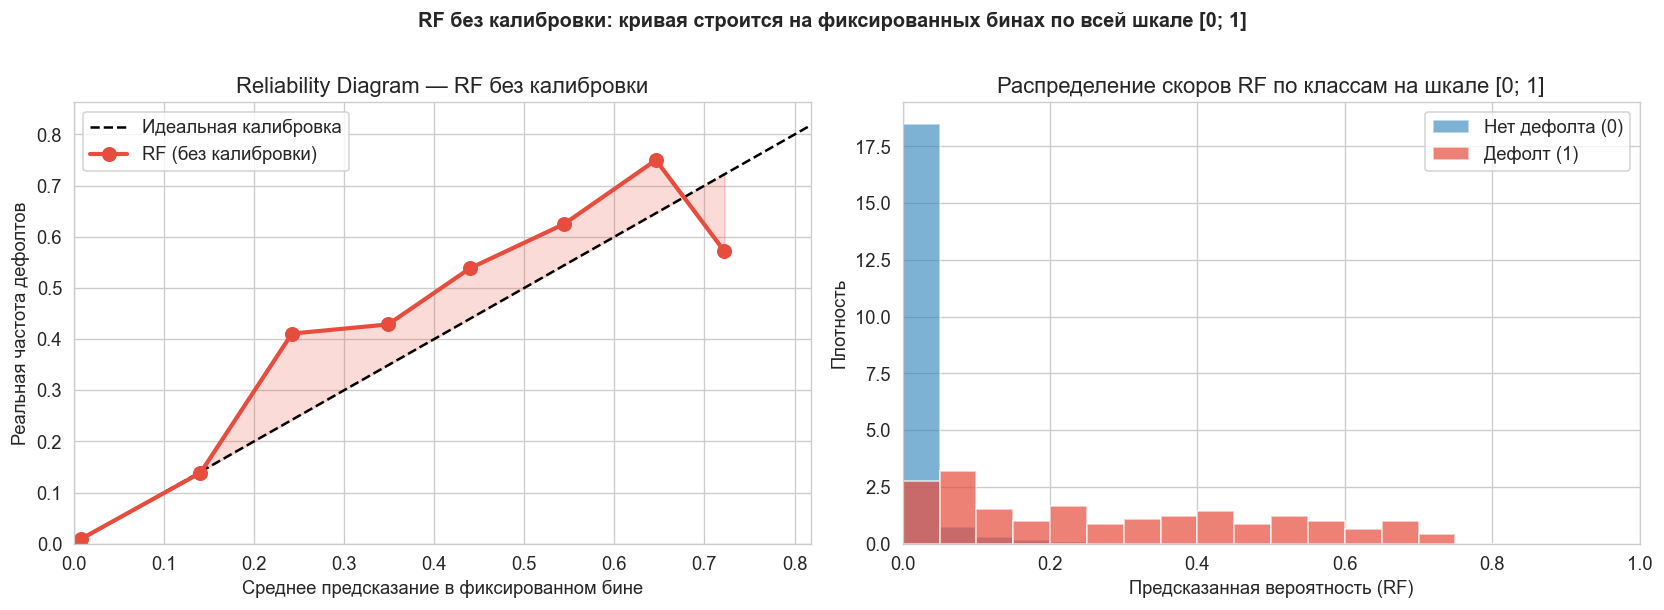

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
mean_pred, frac_pos = get_calibration_curve(y_test.values, scores_test, n_bins=10, strategy="uniform")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка")
ax.plot(mean_pred, frac_pos, "o-", color=COLORS[0], lw=2.5, ms=8, label="RF (без калибровки)")
ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.2, color=COLORS[0])
ax.set_xlabel("Среднее предсказание в фиксированном бине")
ax.set_ylabel("Реальная частота дефолтов")
ax.set_title("Reliability Diagram — RF без калибровки")
ax.legend()

x_max = max(scores_test.max() * 1.1, 0.35)
y_max = max(frac_pos.max() * 1.15, 0.35)
ax.set_xlim(0, min(x_max, 1.0))
ax.set_ylim(0, min(y_max, 1.0))

ax = axes[1]
ax.hist(scores_test[y_test == 0], bins=np.linspace(0, 1, 21), alpha=0.6, label="Нет дефолта (0)", color=COLORS[1], density=True)
ax.hist(scores_test[y_test == 1], bins=np.linspace(0, 1, 21), alpha=0.7, label="Дефолт (1)", color=COLORS[0], density=True)
ax.set_xlim(0, 1)
ax.set_xlabel("Предсказанная вероятность (RF)")
ax.set_ylabel("Плотность")
ax.set_title("Распределение скоров RF по классам на шкале [0; 1]")
ax.legend()

plt.suptitle(
    "RF без калибровки: кривая строится на фиксированных бинах по всей шкале [0; 1]",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


### Почему RF без калибровки может быть неидеальной

Хорошее ранжирование не означает хорошую вероятность дефолта. Random Forest может хорошо отделять дефолтных заемщиков от недефолтных, но его сырые `predict_proba` часто требуют посткалибровки:

- **AUC/Gini/KS** отвечают за порядок заемщиков по риску.
- **Brier, Log-Loss, ECE, calibration slope/intercept** отвечают за качество численных PD.
- Если `slope` заметно отличается от 1, модель неверно масштабирует риск.
- Если `intercept` заметно отличается от 0, модель систематически завышает или занижает уровень PD.

Большой пик недефолтных клиентов в низких PD — это нормально: в кредитном портфеле большинство заемщиков не дефолтит, а хорошая модель должна концентрировать таких клиентов в левой части шкалы.

## 5. Сравнение методов калибровки

В итоговом сравнении оставлена **одна базовая сплайн-модель** — **сплайн-калибровка с монотонным ограничением**.  
Причина: для PD-калибровки монотонность является содержательно предпочтительной, поскольку более высокий исходный риск не должен переводиться в более низкую итоговую PD.

Дополнительно вводится **французский сплайн-калибровка** — двухшаговый метод, в котором:
1. исходные PD сначала калибруются **логит-моделью**;
2. затем полученные логит-калиброванные PD дополнительно сглаживаются **монотонным сплайном**.

Таким образом, в ноутбуке сопоставляются простые параметрические, непараметрические и гибридные методы калибровки PD.

In [8]:
calibrators = get_all_calibrators()
calibrated_probs = {}

for name, cal in calibrators.items():
    cal.fit(scores_calib, y_calib.values)
    calibrated_probs[name] = np.clip(cal.predict(scores_test), 1e-6, 1 - 1e-6)
    print(f"{name}: обучен.")

print("\nВсе калибраторы обучены только на calibration-выборке.")

Logit calibration: обучен.
Isotonic regression: обучен.
Beta calibration: обучен.
Monotone spline: обучен.
French spline: обучен.

Все калибраторы обучены только на calibration-выборке.


Monotone spline vs French spline:
Mean absolute difference: 0.020677
Max absolute difference: 0.042985


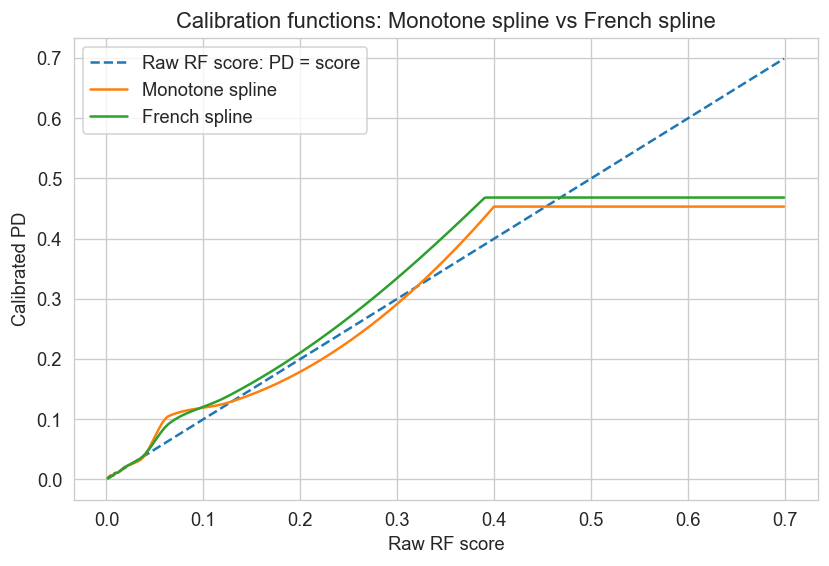

In [9]:
# Compare Monotone spline and French spline calibration functions

score_grid = np.linspace(
    max(1e-4, float(np.quantile(scores_calib, 0.001))),
    min(0.9999, float(np.quantile(scores_calib, 0.999))),
    500,
)

mono = calibrators["Monotone spline"]
french = calibrators["French spline"]

mono_pd = mono.predict(score_grid)
french_pd = french.predict(score_grid)

diff = np.abs(mono_pd - french_pd)

print("Monotone spline vs French spline:")
print(f"Mean absolute difference: {diff.mean():.6f}")
print(f"Max absolute difference: {diff.max():.6f}")

plt.figure(figsize=(8, 5))
plt.plot(score_grid, score_grid, "--", label="Raw RF score: PD = score")
plt.plot(score_grid, mono_pd, label="Monotone spline")
plt.plot(score_grid, french_pd, label="French spline")
plt.xlabel("Raw RF score")
plt.ylabel("Calibrated PD")
plt.title("Calibration functions: Monotone spline vs French spline")
plt.legend()
plt.grid(True)
plt.show()


Сравнение функций калибровки показывает, что монотонный и французский сплайн дают близкие преобразования исходного RF-score в откалиброванную PD. Это объясняется тем, что французский сплайн в текущей реализации сначала применяет логит-калибровку, а затем использует тот же механизм монотонного сплайна. Поскольку логит-калибровка в основном является монотонным преобразованием score и почти не меняет порядок наблюдений, последующее биннирование приводит к близкой итоговой кривой.

Следовательно, близкие значения Brier Score, Log-Loss, ECE и RWA для двух сплайн-методов не являются ошибкой. Они отражают то, что французский сплайн в данной реализации является скорее двухшаговой модификацией обычного монотонного сплайна, а не принципиально отдельным методом.

### Интерпретация критериев выбора метода калибровки

Один метод редко оказывается лучшим одновременно по всем критериям. Поэтому выбор метода калибровки зависит от цели анализа. Если задача состоит в минимизации ошибки вероятностного прогноза, нужно смотреть Brier Score и Log-Loss. Если важна согласованность PD с фактической частотой дефолтов по группам риска, важнее ECE, reliability diagrams и backtesting expected defaults. Если требуется простая и объяснимая модель, логит- и beta-калибровка удобнее как базовые benchmark-методы. Если нужна гладкая PD-кривая для рейтинговой шкалы, полезен монотонный сплайн.

При этом результаты OOT-проверки показывают, что лучший метод по отдельной статистической метрике не обязательно лучше по агрегированному числу дефолтов или по капитальному эффекту. В данном эксперименте калиброванные методы снизили средний уровень PD относительно RF, поэтому их экономия капитала должна интерпретироваться осторожно.

In [10]:
print("Metrics and backtesting are calculated below. Final selection table follows later.")

Metrics and backtesting are calculated below. Final selection table follows later.


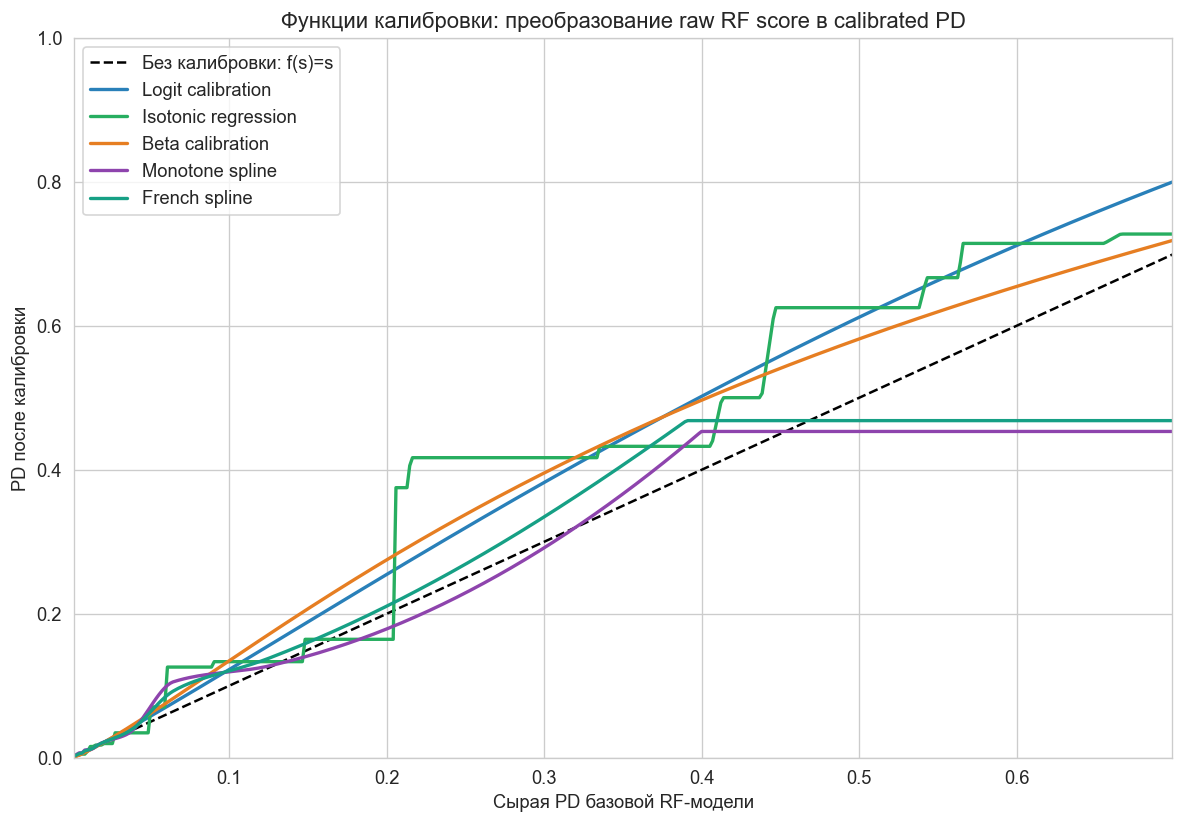

Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.


In [11]:
score_grid = np.linspace(
    max(1e-4, float(np.quantile(scores_calib, 0.001))),
    min(0.9999, float(np.quantile(scores_calib, 0.999))),
    400,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(score_grid, score_grid, "k--", lw=1.5, label="Без калибровки: f(s)=s")

for (name, cal), color in zip(calibrators.items(), COLORS[1:]):
    calibrated_grid = cal.predict(score_grid)
    lw = 3.0 if "сплайн" in name.lower() else 2.0
    ax.plot(score_grid, calibrated_grid, color=color, lw=lw, label=name)

ax.set_xlabel("Сырая PD базовой RF-модели")
ax.set_ylabel("PD после калибровки")
ax.set_title("Функции калибровки: преобразование raw RF score в calibrated PD")
ax.set_xlim(score_grid.min(), score_grid.max())
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.")

In [12]:
parameter_rows = []
for name, cal in calibrators.items():
    row = {"Метод": name}

    if hasattr(cal, "_model") and hasattr(cal._model, "coef_"):
        row["Параметры"] = (
            f"a={float(cal._model.coef_[0][0]):.4f}, "
            f"b={float(cal._model.intercept_[0]):.4f}"
        )
    elif hasattr(cal, "a_"):
        row["Параметры"] = (
            f"a={cal.a_:.4f}, b={cal.b_:.4f}, c={cal.c_:.4f}, "
            f"success={cal.success_}"
        )
    elif hasattr(cal, "bin_stats_") and cal.bin_stats_ is not None:
        row["Параметры"] = f"число бинов={len(cal.bin_stats_)}"
    elif hasattr(cal, "spline_stage"):
        row["Параметры"] = f"logit + spline, число бинов={len(cal.spline_stage.bin_stats_)}"
    else:
        row["Параметры"] = "непараметрический метод"

    parameter_rows.append(row)

display(pd.DataFrame(parameter_rows).set_index("Метод"))

,Параметры
Метод,
Logit calibration,"a=1.1029, b=0.4552"
Isotonic regression,непараметрический метод
Beta calibration,"a=1.2163, b=-0.3935, c=0.9000, success=True"
Monotone spline,число бинов=30
French spline,число бинов=30


## 6. Результаты на OOT: метрики и визуальная диагностика

**Важно для интерпретации графиков.**  
Кривые калибровки в этой версии строятся на **фиксированных бинах по всей шкале [0; 1]**.  
Это исправляет прежнюю проблему, когда при квантильной разбивке последняя точка на оси X показывала лишь **среднее значение верхнего дециля**, поэтому визуально казалось, что все методы обрываются около `0.15`, хотя фактические максимумы PD были выше.

In [13]:
results = [summary_metrics(y_test.values, scores_test, name="RF без калибровки")]
for name, probs in calibrated_probs.items():
    results.append(summary_metrics(y_test.values, probs, name=name))

df_results = pd.DataFrame(results).set_index("method")

print("Метрики на OOT-выборке, 2024 год:")
print("  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше")
print("  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий")
print("  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке")

df_results_ru = df_results.rename(columns={
    "brier_score": "Brier Score",
    "log_loss": "Log-Loss",
    "ece_uniform": "ECE (фикс. бины)",
    "ece_quantile": "ECE (квант. бины)",
    "hl_chi2": "HL chi2",
    "hl_p_value": "HL p-value",
    "cal_slope": "Cal. slope",
    "cal_intercept": "Cal. intercept",
})

display(
    df_results_ru.round({
        "Brier Score": 5,
        "Log-Loss": 5,
        "ECE (фикс. бины)": 5,
        "ECE (квант. бины)": 5,
        "HL chi2": 3,
        "HL p-value": 4,
        "Cal. slope": 4,
        "Cal. intercept": 4,
    })
)

disc_rows = []
all_preds = {"RF без калибровки": scores_test, **calibrated_probs}
for name, probs in all_preds.items():
    disc_rows.append(discrimination_metrics(y_test.values, probs, name=name))

df_disc = pd.DataFrame(disc_rows).set_index("method")
print("\nМетрики ранжирования (AUC / Gini / KS):")
print(df_disc.to_string())
print("\nКомментарий: строго монотонные преобразования обычно сохраняют ранжирование;")
print("изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.")

prob_range_rows = []
for name, probs in all_preds.items():
    prob_range_rows.append({
        "method": name,
        "min_pd": np.min(probs),
        "p95_pd": np.quantile(probs, 0.95),
        "max_pd": np.max(probs),
    })

df_prob_ranges = pd.DataFrame(prob_range_rows).set_index("method")
df_prob_ranges_ru = df_prob_ranges.rename(columns={
    "min_pd": "Мин. PD",
    "p95_pd": "95-й перцентиль PD",
    "max_pd": "Макс. PD",
})
print("\nФактический диапазон PD на OOT:")
display(df_prob_ranges_ru.round(4))

Метрики на OOT-выборке, 2024 год:
  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше
  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий
  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке


,Brier Score,Log-Loss,ece,ECE (фикс. бины),ECE (квант. бины),HL chi2,HL p-value,Cal. slope,Cal. intercept
method,,,,,,,,,
RF без калибровки,0.01907,0.06911,0.00599,0.00480,0.00599,14.025,0.0811,1.1029,0.4552
Logit calibration,0.01881,0.06827,0.00156,0.00238,0.00156,3.184,0.9223,0.9999,0.0000
Isotonic regression,0.01822,0.06576,0.00031,0.00000,0.00031,0.454,0.9937,0.9996,-0.0007
Beta calibration,0.01878,0.06809,0.00119,0.00242,0.00119,2.982,0.9355,0.9991,-0.0009
Monotone spline,0.01941,0.07003,0.00719,0.00707,0.00719,18.977,0.0042,1.2476,0.6668
French spline,0.01923,0.06924,0.00552,0.00428,0.00552,12.046,0.1492,1.1734,0.4884



Метрики ранжирования (AUC / Gini / KS):
                     auc_roc    gini  ks_stat
method                                       
RF без калибровки     0.9545  0.9090   0.8039
Logit calibration     0.9545  0.9090   0.8039
Isotonic regression   0.9576  0.9151   0.8039
Beta calibration      0.9545  0.9090   0.8039
Monotone spline       0.9542  0.9084   0.8039
French spline         0.9543  0.9086   0.8039

Комментарий: строго монотонные преобразования обычно сохраняют ранжирование;
изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.

Фактический диапазон PD на OOT:


,Мин. PD,95-й перцентиль PD,Макс. PD
method,,,
RF без калибровки,0.0012,0.1172,0.7436
Logit calibration,0.0009,0.1453,0.8361
Isotonic regression,0.0000,0.1333,0.7500
Beta calibration,0.0007,0.1599,0.7456
Monotone spline,0.0024,0.1240,0.4531
French spline,0.0017,0.1319,0.4681


### Backtesting методов на исторической структуре OOT-портфеля

После калибровки сравниваем методы не только одной строкой метрик, но и на уровне `2024 × рейтинг`. Это отвечает на вопрос, какой метод лучше сохраняет риск-профиль портфеля по разным рейтингам.


In [14]:
df_test = df.loc[y_test.index].copy()
oot_predictions = {"RF без калибровки": scores_test, **calibrated_probs}

method_summary = method_portfolio_summary(df_test, oot_predictions)
rating_method_panel = compare_methods_by_historical_panel(df_test, oot_predictions)

print("Агрегированный итог по OOT-портфелю, 2024:")
display(
    method_summary[[
        "avg_pd",
        "defaults",
        "expected_defaults",
        "default_gap",
        "calibration_ratio",
    ]]
    .style.format({
        "avg_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "default_gap": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)

print("Детализация по рейтингу на OOT-периоде:")
rating_view_cols = [
    "method",
    "origination_year",
    "rating",
    "n_obs",
    "portfolio_count_share",
    "avg_pd",
    "pd_min",
    "pd_max",
    "observed_default_rate",
    "expected_defaults",
    "defaults",
    "calibration_ratio",
]
display(
    rating_method_panel[rating_view_cols]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "avg_pd": "{:.2%}",
        "pd_min": "{:.2%}",
        "pd_max": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)


Агрегированный итог по OOT-портфелю, 2024:


,avg_pd,defaults,expected_defaults,default_gap,calibration_ratio
method,,,,,
RF без калибровки,2.40%,181.000000,153.21,27.79,1.18
Logit calibration,2.84%,181.000000,181.01,-0.01,1.00
Isotonic regression,2.84%,181.000000,181.00,-0.00,1.00
Beta calibration,2.84%,181.000000,181.00,0.00,1.00
Monotone spline,2.52%,181.000000,160.82,20.18,1.13
French spline,2.55%,181.000000,162.53,18.47,1.11


Детализация по рейтингу на OOT-периоде:


,method,origination_year,rating,n_obs,portfolio_count_share,avg_pd,pd_min,pd_max,observed_default_rate,expected_defaults,defaults,calibration_ratio
0,RF без калибровки,2024,A,3304,51.9%,0.17%,0.12%,1.59%,0.09%,5.77,3,0.52
1,RF без калибровки,2024,B,2097,32.9%,0.63%,0.13%,6.90%,0.43%,13.20,9,0.68
2,RF без калибровки,2024,C,784,12.3%,7.78%,0.53%,58.99%,9.95%,60.98,78,1.28
3,RF без калибровки,2024,D,187,2.9%,39.17%,7.30%,74.36%,48.66%,73.25,91,1.24
4,Logit calibration,2024,A,3304,51.9%,0.14%,0.09%,1.64%,0.09%,4.76,3,0.63
5,Logit calibration,2024,B,2097,32.9%,0.61%,0.10%,8.20%,0.43%,12.71,9,0.71
6,Logit calibration,2024,C,784,12.3%,9.44%,0.49%,70.19%,9.95%,74.04,78,1.05
7,Logit calibration,2024,D,187,2.9%,47.86%,8.73%,83.61%,48.66%,89.49,91,1.02
8,Isotonic regression,2024,A,3304,51.9%,0.06%,0.00%,1.75%,0.09%,2.10,3,1.43
9,Isotonic regression,2024,B,2097,32.9%,0.58%,0.00%,12.58%,0.43%,12.26,9,0.73


### Как выбирать метод калибровки

Один метод редко является лучшим по всем критериям одновременно. Поэтому ниже метод выбирается не только по статистической метрике, но и по практической роли в банковской модели.

In [15]:
selection_table = pd.DataFrame([
    {
        "Сценарий выбора": "Минимизировать Brier / Log-Loss",
        "Что смотреть": "Brier Score, Log-Loss",
        "Типичный кандидат": df_results["brier_score"].idxmin(),
        "Комментарий": "Лучше для чистого качества вероятностного прогноза.",
    },
    {
        "Сценарий выбора": "Минимизировать ошибку калибровки",
        "Что смотреть": "ECE на квантильных и фиксированных бинах",
        "Типичный кандидат": df_results["ece_quantile"].idxmin(),
        "Комментарий": "Полезно для reliability diagrams и backtesting PD.",
    },
    {
        "Сценарий выбора": "Сохранить простоту и интерпретируемость",
        "Что смотреть": "Стабильность, slope/intercept, governance",
        "Типичный кандидат": "Логит-калибровка / Бета-калибровка",
        "Комментарий": "Хорошие базовые benchmark-методы.",
    },
    {
        "Сценарий выбора": "Получить гладкую PD-кривую",
        "Что смотреть": "ECE, графики, отсутствие ступеней",
        "Типичный кандидат": "Монотонный сплайн / Французский сплайн",
        "Комментарий": "Удобно для банковской master scale и презентации калибровочной функции.",
    },
    {
        "Сценарий выбора": "Оценить capital impact",
        "Что смотреть": "RWA, required capital, H1 if keep raw capital",
        "Типичный кандидат": "Определяется отдельно в RWA-блоке",
        "Комментарий": "Лучший по Brier метод не обязан давать минимальный капитал.",
    },
])

display(selection_table)

,Сценарий выбора,Что смотреть,Типичный кандидат,Комментарий
0,Минимизировать Brier / Log-Loss,"Brier Score, Log-Loss",Isotonic regression,Лучше для чистого качества вероятностного прог...
1,Минимизировать ошибку калибровки,ECE на квантильных и фиксированных бинах,Isotonic regression,Полезно для reliability diagrams и backtesting...
2,Сохранить простоту и интерпретируемость,"Стабильность, slope/intercept, governance",Логит-калибровка / Бета-калибровка,Хорошие базовые benchmark-методы.
3,Получить гладкую PD-кривую,"ECE, графики, отсутствие ступеней",Монотонный сплайн / Французский сплайн,Удобно для банковской master scale и презентац...
4,Оценить capital impact,"RWA, required capital, H1 if keep raw capital",Определяется отдельно в RWA-блоке,Лучший по Brier метод не обязан давать минимал...


### Backtesting методов на исторической структуре OOT-портфеля

In [16]:
# =========================
# Диагностическая intercept recalibration
# =========================
# Цель: проверить, связана ли ошибка OOT-бэктеста
# преимущественно со сдвигом общего уровня PD.
#
# ВАЖНО:
# Здесь target_pd = фактическая дефолтность OOT.
# Это диагностический / oracle-сценарий, а не честная production-настройка.
# В реальной задаче target_pd должен задаваться заранее:
# например, из макропрогноза, исторической дефолтности или risk appetite.

from scipy.optimize import brentq
from scipy.special import expit

EPS_PD = 1e-6


def logit_transform(p):
    p = np.clip(np.asarray(p, dtype=float), EPS_PD, 1 - EPS_PD)
    return np.log(p / (1 - p))


def intercept_recalibrate_to_target(pd_values, target_pd, sample_weight=None):
    """
    Сдвигает PD на logit-шкале:

        logit(PD_new) = logit(PD_old) + delta

    Подбирает delta так, чтобы средняя PD совпала с target_pd.
    Ранжирование заемщиков при этом сохраняется.
    """

    p = np.clip(np.asarray(pd_values, dtype=float), EPS_PD, 1 - EPS_PD)

    if sample_weight is None:
        weights = np.ones(len(p), dtype=float)
    else:
        weights = np.asarray(sample_weight, dtype=float)

    logits = logit_transform(p)

    def objective(delta):
        shifted_pd = expit(logits + delta)
        return np.average(shifted_pd, weights=weights) - target_pd

    delta = brentq(objective, -50, 50)
    p_new = np.clip(expit(logits + delta), EPS_PD, 1 - EPS_PD)

    return p_new, float(delta)


# Базовые прогнозы на OOT
base_predictions = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

# Диагностический target: фактическая дефолтность OOT
# В production-логике это значение нельзя брать из y_test.
TARGET_PD_INTERCEPT = float(y_test.mean())

intercept_adjusted_probs = {}
intercept_rows = []

for name, probs in base_predictions.items():
    probs_adj, delta = intercept_recalibrate_to_target(
        probs,
        target_pd=TARGET_PD_INTERCEPT,
        sample_weight=np.ones(len(y_test), dtype=float),
    )

    new_name = f"{name} + intercept"
    intercept_adjusted_probs[new_name] = probs_adj

    intercept_rows.append({
        "method": name,
        "target_default_rate": TARGET_PD_INTERCEPT,
        "avg_pd_before": float(np.mean(probs)),
        "avg_pd_after": float(np.mean(probs_adj)),
        "delta_logit": delta,
        "actual_defaults": int(y_test.sum()),
        "expected_defaults_before": float(np.sum(probs)),
        "expected_defaults_after": float(np.sum(probs_adj)),
        "gap_before": float(y_test.sum() - np.sum(probs)),
        "gap_after": float(y_test.sum() - np.sum(probs_adj)),
    })

df_intercept_shift = pd.DataFrame(intercept_rows).set_index("method")

display(
    df_intercept_shift.style.format({
        "target_default_rate": "{:.2%}",
        "avg_pd_before": "{:.2%}",
        "avg_pd_after": "{:.2%}",
        "delta_logit": "{:.4f}",
        "actual_defaults": "{:.0f}",
        "expected_defaults_before": "{:.2f}",
        "expected_defaults_after": "{:.2f}",
        "gap_before": "{:.2f}",
        "gap_after": "{:.2f}",
    })
)

,target_default_rate,avg_pd_before,avg_pd_after,delta_logit,actual_defaults,expected_defaults_before,expected_defaults_after,gap_before,gap_after
method,,,,,,,,,
RF без калибровки,2.84%,2.40%,2.84%,0.2370,181,153.21,181.00,27.79,-0.00
Logit calibration,2.84%,2.84%,2.84%,-0.0001,181,181.01,181.00,-0.01,-0.00
Isotonic regression,2.84%,2.84%,2.84%,-0.0000,181,181.00,181.00,-0.00,-0.00
Beta calibration,2.84%,2.84%,2.84%,0.0000,181,181.00,181.00,0.00,-0.00
Monotone spline,2.84%,2.52%,2.84%,0.1543,181,160.82,181.00,20.18,0.00
French spline,2.84%,2.55%,2.84%,0.1450,181,162.53,181.00,18.47,0.00


In [17]:
# =========================
# Сравнение статистических метрик до и после intercept recalibration
# =========================

metric_rows = []

for name, probs in base_predictions.items():
    before = summary_metrics(y_test.values, probs, name=name)
    before["base_method"] = name
    before["variant"] = "до intercept"

    after_probs = intercept_adjusted_probs[f"{name} + intercept"]
    after = summary_metrics(y_test.values, after_probs, name=f"{name} + intercept")
    after["base_method"] = name
    after["variant"] = "после intercept"

    metric_rows.extend([before, after])

df_intercept_metrics = pd.DataFrame(metric_rows)

metric_cols = [
    "brier_score",
    "log_loss",
    "ece_uniform",
    "ece_quantile",
    "hl_chi2",
    "hl_p_value",
    "cal_slope",
    "cal_intercept",
]

display(
    df_intercept_metrics
    .set_index(["base_method", "variant"])[metric_cols]
    .style.format({
        "brier_score": "{:.5f}",
        "log_loss": "{:.5f}",
        "ece_uniform": "{:.5f}",
        "ece_quantile": "{:.5f}",
        "hl_chi2": "{:.3f}",
        "hl_p_value": "{:.4f}",
        "cal_slope": "{:.4f}",
        "cal_intercept": "{:.4f}",
    })
)

In [18]:
# =========================
# Проверка сохранения ранжирования
# =========================

disc_rows = []

for name, probs in base_predictions.items():
    before = discrimination_metrics(y_test.values, probs, name=name)
    before["base_method"] = name
    before["variant"] = "до intercept"

    after_probs = intercept_adjusted_probs[f"{name} + intercept"]
    after = discrimination_metrics(y_test.values, after_probs, name=f"{name} + intercept")
    after["base_method"] = name
    after["variant"] = "после intercept"

    disc_rows.extend([before, after])

df_intercept_disc = pd.DataFrame(disc_rows)

display(
    df_intercept_disc
    .set_index(["base_method", "variant"])[["auc_roc", "gini", "ks_stat"]]
    .style.format({
        "auc_roc": "{:.4f}",
        "gini": "{:.4f}",
        "ks_stat": "{:.4f}",
    })
)

In [19]:
# =========================
# Backtesting expected defaults после intercept recalibration
# =========================

df_test = df.loc[y_test.index].copy()

oot_predictions_intercept_experiment = {
    **base_predictions,
    **intercept_adjusted_probs,
}

method_summary_intercept = method_portfolio_summary(
    df_test,
    oot_predictions_intercept_experiment,
)

method_summary_intercept["abs_default_gap"] = method_summary_intercept["default_gap"].abs()

display(
    method_summary_intercept[[
        "avg_pd",
        "defaults",
        "expected_defaults",
        "default_gap",
        "abs_default_gap",
        "calibration_ratio",
    ]]
    .sort_values("abs_default_gap")
    .style.format({
        "avg_pd": "{:.2%}",
        "defaults": "{:.0f}",
        "expected_defaults": "{:.2f}",
        "default_gap": "{:.2f}",
        "abs_default_gap": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)

,avg_pd,defaults,expected_defaults,default_gap,abs_default_gap,calibration_ratio
method,,,,,,
RF без калибровки + intercept,2.84%,181,181.00,-0.00,0.00,1.00
French spline + intercept,2.84%,181,181.00,0.00,0.00,1.00
Monotone spline + intercept,2.84%,181,181.00,0.00,0.00,1.00
Beta calibration + intercept,2.84%,181,181.00,-0.00,0.00,1.00
Logit calibration + intercept,2.84%,181,181.00,-0.00,0.00,1.00
Isotonic regression + intercept,2.84%,181,181.00,-0.00,0.00,1.00
Beta calibration,2.84%,181,181.00,0.00,0.00,1.00
Isotonic regression,2.84%,181,181.00,-0.00,0.00,1.00
Logit calibration,2.84%,181,181.01,-0.01,0.01,1.00


Дополнительный эксперимент с intercept recalibration подтвердил, что проблема OOT-бэктеста во многом связана не с потерей ранжирующей способности модели, а со сдвигом базового уровня дефолтности в тестовом периоде. После сдвига PD на logit-шкале средний прогнозный PD был приведен к фактической дефолтности OOT, при этом ранжирующие метрики практически не изменились. Следовательно, исходные калибраторы сохраняют способность различать заемщиков по уровню риска, но требуют корректировки общего уровня PD при изменении макроэкономического режима.

### Эффект калибровки на резервы, RWA и требуемый капитал

После статистического сравнения каждая версия PD переводится в прикладные показатели: **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%** и **Capital_true**. Это позволяет оценить не только качество калибровки как статистической процедуры, но и её влияние на капитальную нагрузку портфеля.

Для чистоты сравнения используется фиксированное допущение **EAD = 1 000 000** на каждое наблюдение и **LGD = 40%**. Поэтому различия между методами интерпретируются как эффект именно от калиброванной **PD**, а не от разного размера экспозиции.

Дополнительно рассчитывается, сколько капитала можно высвободить относительно **сырых PD** при целевом нормативе **H1 = 8%**, а также каким станет фактический **H1**, если сохранить капитал, достаточный для некалиброванной базовой модели.

### Мастер-шкала PD: распределение 2024 по фиксированным границам

В этом блоке рейтинг `A1 ... E` назначается не равными квантилями score, а по фиксированным границам PD из мастер-шкалы. Поэтому доли портфеля по рейтингам могут быть неравномерными: это нормальное поведение и именно оно используется для расчета RWA. Для каждого рейтинга отдельно выводятся средняя, минимальная и максимальная PD внутри бакета, а капитал считается по среднему значению мастер-шкалы с отдельной чувствительностью к нижней и верхней границе.

In [20]:
TARGET_CT = float(y_calib.mean())
ASSET_EAD = 1_000_000.0

df_test_master = df.loc[y_test.index].copy()

excel_logit = LogisticRegression(solver="lbfgs", max_iter=1000, C=1e12)
excel_logit.fit(scores_calib.reshape(-1, 1), y_calib.values)
excel_logit_pd = np.clip(
    excel_logit.predict_proba(scores_test.reshape(-1, 1))[:, 1],
    1e-6,
    1 - 1e-6,
)

rating_scale_predictions = {
    "Excel logit(score)": excel_logit_pd,
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

master_scale_panel = method_master_scale_distribution(
    df_test_master,
    rating_scale_predictions,
    default_asset_ead=ASSET_EAD,
).copy()

score_by_rating_rows = []
for method, pd_values in rating_scale_predictions.items():
    rating_by_pd = assign_pd_master_scale_ratings(pd_values)
    score_work = pd.DataFrame({"rating": rating_by_pd, "score": scores_test})
    score_by_rating = (
        score_work.groupby("rating", observed=False)["score"]
        .mean()
        .reindex(MASTER_SCALE_RATINGS)
        .reset_index(name="avg_score")
    )
    score_by_rating["method"] = method
    score_by_rating_rows.append(score_by_rating)

master_scale_panel = master_scale_panel.merge(
    pd.concat(score_by_rating_rows, ignore_index=True),
    on=["method", "rating"],
    how="left",
)

# Для RWA используем среднее значение PD из заданной мастер-шкалы.
# Фактическая средняя PD внутри бакета остается в колонке avg_pd.
master_scale_panel["pd_rating"] = master_scale_panel["pd_avg_master"]
master_scale_panel["pd_before_target"] = master_scale_panel["avg_pd"]
master_scale_panel["one_minus_pd"] = 1.0 - master_scale_panel["pd_rating"]
master_scale_panel["expected_defaults"] = master_scale_panel["pd_rating"] * master_scale_panel["n_assets"]
master_scale_panel["expected_default_ead"] = master_scale_panel["pd_rating"] * master_scale_panel["total_ead"]
master_scale_panel["default_gap"] = master_scale_panel["defaults"] - master_scale_panel["expected_defaults"]
master_scale_panel["calibration_ratio"] = np.where(
    master_scale_panel["expected_defaults"] > 0.0,
    master_scale_panel["defaults"] / master_scale_panel["expected_defaults"],
    np.nan,
)

summary_rows = []
for method, frame in master_scale_panel.groupby("method", sort=False):
    active = frame[frame["n_assets"] > 0].copy()
    total_ead = active["total_ead"].sum()
    summary_rows.append({
        "method": method,
        "n_assets": int(active["n_assets"].sum()),
        "total_ead": float(total_ead),
        "defaults": float(active["defaults"].sum()),
        "target_weighted_pd": float(np.average(active["pd_rating"], weights=active["total_ead"])),
        "avg_individual_pd": float(np.average(active["avg_pd"], weights=active["n_assets"])),
        "expected_defaults": float(active["expected_defaults"].sum()),
        "pd_min": float(active["pd_min"].min()),
        "pd_max": float(active["pd_max"].max()),
    })
master_scale_summary = pd.DataFrame(summary_rows).set_index("method")

master_scale_assumptions = IRBAssumptions(lgd=0.40, maturity_years=2.5, ead=ASSET_EAD)

master_scale_capital = rating_scale_capital(
    master_scale_panel,
    assumptions=master_scale_assumptions,
    method_col="method",
)

rwa_rating_rows = []
for row in master_scale_panel.loc[master_scale_panel["total_ead"] > 0].itertuples(index=False):
    capital_row = calculate_845p_capital(
        [row.pd_rating],
        assumptions=master_scale_assumptions,
        ead_values=[row.total_ead],
    ).iloc[0]
    rwa_rating_rows.append({
        "method": row.method,
        "rating": row.rating,
        "n_assets": row.n_assets,
        "portfolio_count_share": row.portfolio_count_share,
        "observed_default_rate": row.observed_default_rate,
        "total_ead": row.total_ead,
        "pd_min": row.pd_min,
        "avg_pd": row.avg_pd,
        "pd_max": row.pd_max,
        "pd_rating": row.pd_rating,
        "total_expected_loss": capital_row["Reserves"],
        "total_rwa": capital_row["RWA_capital"],
        "total_required_capital": capital_row["Capital_true"],
    })

master_scale_rwa_by_rating = pd.DataFrame(rwa_rating_rows)
master_scale_rwa_by_rating["rating"] = pd.Categorical(
    master_scale_rwa_by_rating["rating"],
    categories=MASTER_SCALE_RATINGS,
    ordered=True,
)
master_scale_rwa_by_rating = master_scale_rwa_by_rating.sort_values(["method", "rating"])
master_scale_rwa_by_rating["rwa_share"] = (
    master_scale_rwa_by_rating["total_rwa"]
    / master_scale_rwa_by_rating.groupby("method")["total_rwa"].transform("sum")
)
master_scale_rwa_by_rating["capital_share"] = (
    master_scale_rwa_by_rating["total_required_capital"]
    / master_scale_rwa_by_rating.groupby("method")["total_required_capital"].transform("sum")
)

rwa_sync_check = (
    master_scale_rwa_by_rating
    .groupby("method", observed=False)[["total_expected_loss", "total_rwa", "total_required_capital"]]
    .sum()
    .join(
        master_scale_capital[["total_expected_loss", "total_rwa", "total_required_capital"]],
        lsuffix="_by_rating",
        rsuffix="_summary",
    )
)
for metric in ["total_expected_loss", "total_rwa", "total_required_capital"]:
    rwa_sync_check[f"{metric}_diff"] = (
        rwa_sync_check[f"{metric}_by_rating"] - rwa_sync_check[f"{metric}_summary"]
    ).abs()

max_rwa_sync_diff = float(
    rwa_sync_check[[col for col in rwa_sync_check.columns if col.endswith("_diff")]].max().max()
)
if max_rwa_sync_diff > 1e-4:
    raise ValueError("RWA tables are not synchronized with the master-scale summary.")

master_scale_method = list(calibrated_probs.keys())[-1]
master_scale_bounds = (
    master_scale_panel.loc[
        master_scale_panel["method"] == master_scale_method,
        ["rating", "pd_lower", "pd_avg_master", "pd_upper"],
    ]
    .drop_duplicates(subset=["rating"])
    .set_index("rating")
    .reindex(MASTER_SCALE_RATINGS)
)

rating_pd_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="avg_pd")
    .reindex(MASTER_SCALE_RATINGS)
)

print(f"Target CT по calibration-периоду: {TARGET_CT:.2%}")
print(f"OOT default rate:                 {y_test.mean():.2%}")
print(f"EAD на один актив:                {ASSET_EAD:,.0f}")
print("Границы фиксированной мастер-шкалы PD:")
display(
    master_scale_bounds.style.format({
        "pd_lower": "{:.2%}",
        "pd_avg_master": "{:.2%}",
        "pd_upper": "{:.2%}",
    })
)

print("Средняя индивидуальная PD внутри рейтинга по методам калибровки:")
display(rating_pd_matrix.style.format("{:.2%}"))

print("Итог по методам: средняя PD мастер-шкалы, средняя индивидуальная PD и диапазон PD:")
display(
    master_scale_summary[[
        "n_assets",
        "target_weighted_pd",
        "avg_individual_pd",
        "defaults",
        "expected_defaults",
        "pd_min",
        "pd_max",
    ]]
    .style.format({
        "target_weighted_pd": "{:.2%}",
        "avg_individual_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "pd_min": "{:.2%}",
        "pd_max": "{:.2%}",
    })
)

master_scale_view_cols = [
    "rating",
    "avg_score",
    "n_assets",
    "portfolio_count_share",
    "observed_default_rate",
    "pd_min",
    "avg_pd",
    "pd_max",
    "pd_lower",
    "pd_rating",
    "pd_upper",
    "expected_defaults",
]
print(f"Распределение портфеля по фиксированной мастер-шкале: {master_scale_method}")
display(
    master_scale_panel.loc[
        (master_scale_panel["method"] == master_scale_method)
        & (master_scale_panel["n_assets"] > 0),
        master_scale_view_cols,
    ]
    .style.format({
        "avg_score": "{:.4f}",
        "portfolio_count_share": "{:.1%}",
        "observed_default_rate": "{:.2%}",
        "pd_min": "{:.2%}",
        "avg_pd": "{:.2%}",
        "pd_max": "{:.2%}",
        "pd_lower": "{:.2%}",
        "pd_rating": "{:.2%}",
        "pd_upper": "{:.2%}",
        "expected_defaults": "{:.2f}",
    })
)


Target CT по calibration-периоду: 2.84%
OOT default rate:                 2.84%
EAD на один актив:                1,000,000
Границы фиксированной мастер-шкалы PD:


,pd_lower,pd_avg_master,pd_upper
rating,,,
A1,0.00%,0.05%,0.06%
A2,0.06%,0.07%,0.08%
A3,0.08%,0.09%,0.10%
B1,0.10%,0.12%,0.14%
B2,0.14%,0.22%,0.30%
B3,0.30%,0.47%,0.65%
C1,0.65%,0.85%,1.05%
C2,1.05%,1.55%,1.82%
C3,1.82%,1.61%,2.91%


Средняя индивидуальная PD внутри рейтинга по методам калибровки:


method,Beta calibration,Excel logit(score),French spline,Isotonic regression,Logit calibration,Monotone spline,RF без калибровки
rating,,,,,,,
A1,nan%,nan%,nan%,0.03%,nan%,nan%,nan%
A2,0.08%,nan%,nan%,nan%,nan%,nan%,nan%
A3,0.09%,nan%,nan%,nan%,0.10%,nan%,nan%
B1,0.12%,nan%,nan%,nan%,0.12%,nan%,0.13%
B2,0.20%,nan%,0.20%,0.19%,0.19%,0.27%,0.19%
B3,0.45%,nan%,0.46%,0.41%,0.45%,0.46%,0.45%
C1,0.82%,nan%,0.86%,0.90%,0.82%,0.70%,0.82%
C2,1.38%,1.16%,1.29%,1.65%,1.38%,1.21%,1.36%
C3,2.29%,2.27%,2.31%,1.96%,2.30%,2.34%,2.27%


Итог по методам: средняя PD мастер-шкалы, средняя индивидуальная PD и диапазон PD:


,n_assets,target_weighted_pd,avg_individual_pd,defaults,expected_defaults,pd_min,pd_max
method,,,,,,,
Excel logit(score),6372,2.66%,2.84%,181.000000,169.74,1.11%,97.67%
RF без калибровки,6372,2.35%,2.40%,181.000000,149.91,0.12%,74.36%
Logit calibration,6372,2.58%,2.84%,181.000000,164.49,0.09%,83.61%
Isotonic regression,6372,2.45%,2.84%,181.000000,156.01,0.00%,75.00%
Beta calibration,6372,2.63%,2.84%,181.000000,167.47,0.07%,74.56%
Monotone spline,6372,2.50%,2.52%,181.000000,158.99,0.24%,45.31%
French spline,6372,2.53%,2.55%,181.000000,161.47,0.17%,46.81%


Распределение портфеля по фиксированной мастер-шкале: French spline


,rating,avg_score,n_assets,portfolio_count_share,observed_default_rate,pd_min,avg_pd,pd_max,pd_lower,pd_rating,pd_upper,expected_defaults
82,B2,0.0016,3025,47.5%,0.07%,0.17%,0.20%,0.30%,0.14%,0.22%,0.30%,6.66
83,B3,0.0038,1712,26.9%,0.29%,0.30%,0.46%,0.65%,0.30%,0.47%,0.65%,8.05
84,C1,0.0080,386,6.1%,0.78%,0.65%,0.86%,1.05%,0.65%,0.85%,1.05%,3.28
85,C2,0.0127,283,4.4%,1.41%,1.05%,1.29%,1.82%,1.05%,1.55%,1.82%,4.39
86,C3,0.0222,164,2.6%,2.44%,1.82%,2.31%,2.91%,1.82%,1.61%,2.91%,2.64
87,D1,0.0375,163,2.6%,3.07%,2.91%,3.96%,5.65%,2.91%,4.05%,5.76%,6.60
88,D2,0.0788,340,5.3%,11.76%,5.77%,10.13%,14.03%,5.76%,10.32%,14.07%,35.09
89,D3,0.1746,124,1.9%,21.77%,14.07%,18.53%,25.72%,14.07%,19.98%,26.00%,24.78
90,E,0.4403,175,2.7%,52.00%,26.20%,42.17%,46.81%,26.00%,40.00%,100.00%,70.00


1. Равномерная доля по `A1 ... E` возникает только при квантильной нарезке score; этот подход больше не используется как финальная мастер-шкала.
2. В итоговом блоке рейтинг назначается по PD-границам мастер-шкалы, поэтому разные калибровки могут давать разное распределение заемщиков по рейтингам.
3. Колонки `pd_min`, `avg_pd`, `pd_max` показывают фактический диапазон индивидуальных PD внутри рейтинга; `pd_lower`, `pd_rating`, `pd_upper` — заданные значения мастер-шкалы для RWA.
4. `Expected loss + unexpected loss = capital` отражено в расчете 845-П: резервы интерпретируются как expected loss, а `RWA_capital` — как unexpected loss.

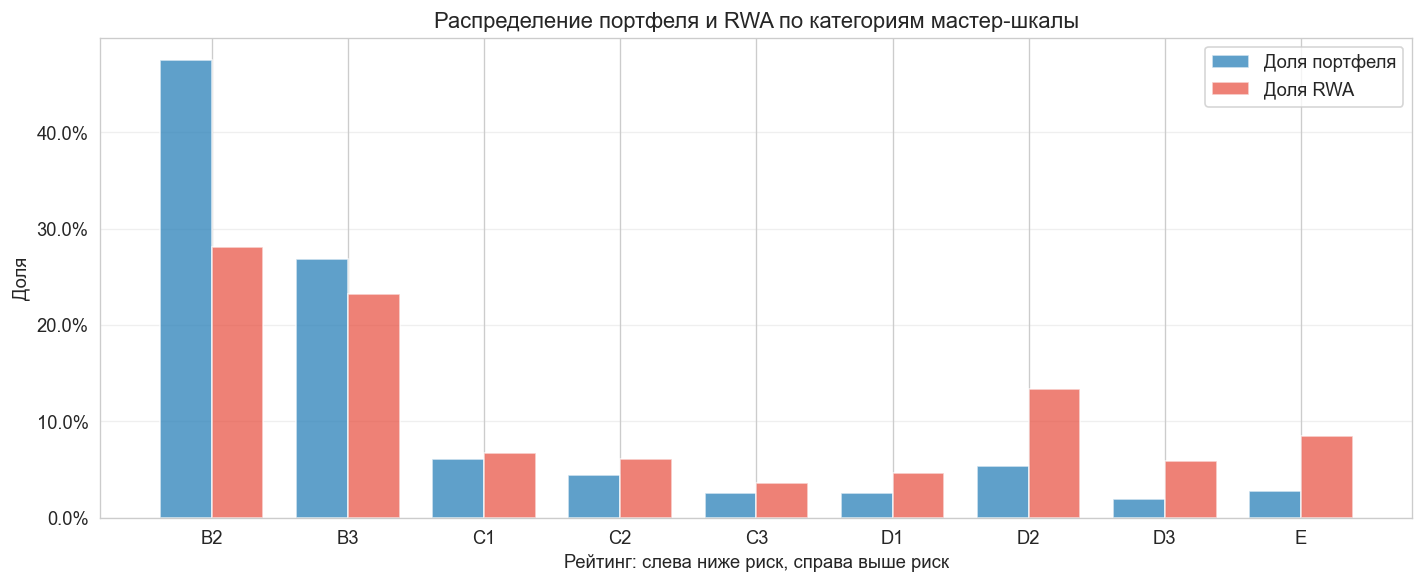

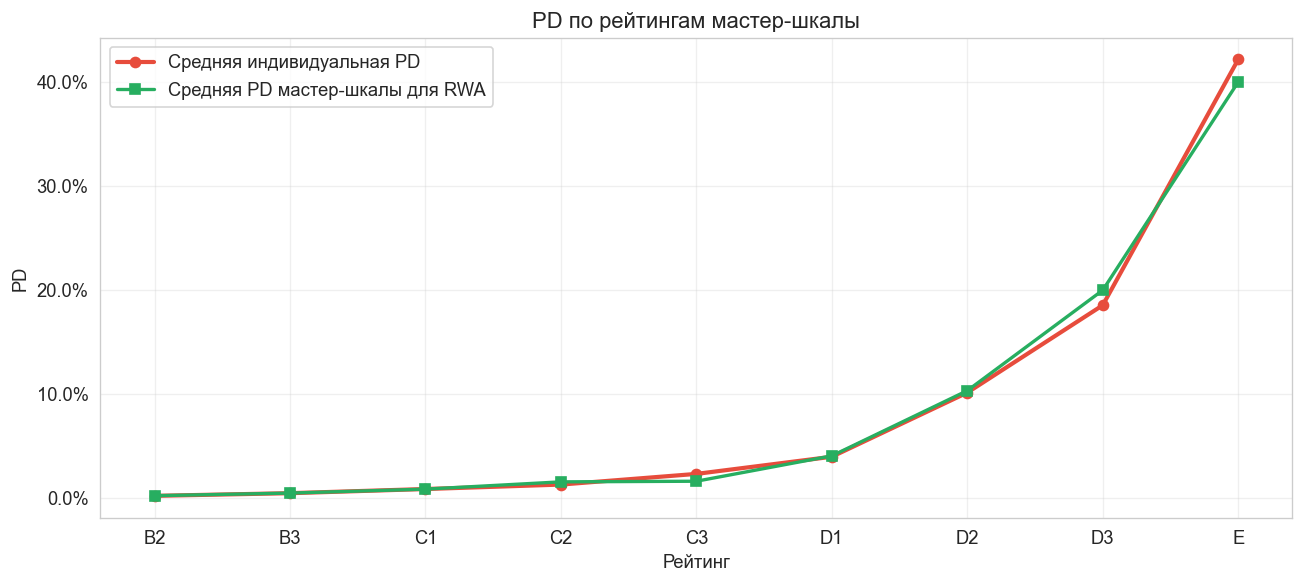

RWA по рейтингам из той же таблицы, что используется для графика:


,rating,n_assets,portfolio_count_share,pd_min,avg_pd,pd_max,pd_rating,total_expected_loss,total_rwa,rwa_share,total_required_capital
58,B2,3025,47.5%,0.17%,0.20%,0.30%,0.22%,"2,662,000","99,418,873",28.1%,"102,080,873"
59,B3,1712,26.9%,0.30%,0.46%,0.65%,0.47%,"3,218,560","82,380,522",23.3%,"85,599,082"
60,C1,386,6.1%,0.65%,0.86%,1.05%,0.85%,"1,312,400","23,860,292",6.7%,"25,172,692"
61,C2,283,4.4%,1.05%,1.29%,1.82%,1.55%,"1,754,600","21,463,109",6.1%,"23,217,709"
62,C3,164,2.6%,1.82%,2.31%,2.91%,1.61%,"1,056,160","12,580,763",3.6%,"13,636,923"
63,D1,163,2.6%,2.91%,3.96%,5.65%,4.05%,"2,640,600","16,239,945",4.6%,"18,880,545"
64,D2,340,5.3%,5.77%,10.13%,14.03%,10.32%,"14,035,200","47,228,690",13.3%,"61,263,890"
65,D3,124,1.9%,14.07%,18.53%,25.72%,19.98%,"9,910,080","21,002,466",5.9%,"30,912,546"
66,E,175,2.7%,26.20%,42.17%,46.81%,40.00%,"28,000,000","29,844,294",8.4%,"57,844,294"


Проверка синхронизации таблиц RWA: максимальное расхождение = 0.000000


,total_ead,total_expected_loss,total_rwa,total_required_capital,rwa_rate_to_ead
method,,,,,
Beta calibration,"6,372,000,000","66,987,840","300,535,140","367,522,980",4.72%
Excel logit(score),"6,372,000,000","67,896,960","508,728,222","576,625,182",7.98%
French spline,"6,372,000,000","64,589,600","354,018,952","418,608,552",5.56%
Isotonic regression,"6,372,000,000","62,405,720","285,010,306","347,416,026",4.47%
Logit calibration,"6,372,000,000","65,796,240","321,974,157","387,770,397",5.05%
Monotone spline,"6,372,000,000","63,597,720","368,711,412","432,309,132",5.79%
RF без калибровки,"6,372,000,000","59,964,400","331,905,978","391,870,378",5.21%


In [21]:
plot_scale = master_scale_rwa_by_rating[
    master_scale_rwa_by_rating["method"] == master_scale_method
].copy()
plot_scale["rating"] = plot_scale["rating"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_scale))
width = 0.38
ax.bar(
    x - width / 2,
    plot_scale["portfolio_count_share"],
    width=width,
    color=COLORS[1],
    alpha=0.75,
    label="Доля портфеля",
)
ax.bar(
    x + width / 2,
    plot_scale["rwa_share"],
    width=width,
    color=COLORS[0],
    alpha=0.70,
    label="Доля RWA",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_scale["rating"])
ax.set_xlabel("Рейтинг: слева ниже риск, справа выше риск")
ax.set_ylabel("Доля")
ax.set_title("Распределение портфеля и RWA по категориям мастер-шкалы")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    plot_scale["rating"],
    plot_scale["avg_pd"],
    marker="o",
    linewidth=2.5,
    color=COLORS[0],
    label="Средняя индивидуальная PD",
)
ax.plot(
    plot_scale["rating"],
    plot_scale["pd_rating"],
    marker="s",
    linewidth=2.0,
    color=COLORS[2],
    label="Средняя PD мастер-шкалы для RWA",
)
ax.set_xlabel("Рейтинг")
ax.set_ylabel("PD")
ax.set_title("PD по рейтингам мастер-шкалы")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("RWA по рейтингам из той же таблицы, что используется для графика:")
display(
    plot_scale[[
        "rating",
        "n_assets",
        "portfolio_count_share",
        "pd_min",
        "avg_pd",
        "pd_max",
        "pd_rating",
        "total_expected_loss",
        "total_rwa",
        "rwa_share",
        "total_required_capital",
    ]]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "pd_min": "{:.2%}",
        "avg_pd": "{:.2%}",
        "pd_max": "{:.2%}",
        "pd_rating": "{:.2%}",
        "total_expected_loss": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "rwa_share": "{:.1%}",
        "total_required_capital": "{:,.0f}",
    })
)

print(f"Проверка синхронизации таблиц RWA: максимальное расхождение = {max_rwa_sync_diff:,.6f}")

display(
    master_scale_capital[[
        "total_ead",
        "total_expected_loss",
        "total_rwa",
        "total_required_capital",
        "rwa_rate_to_ead",
    ]]
    .style.format({
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "rwa_rate_to_ead": "{:.2%}",
    })
)


### Контроль синхронизации таблиц и графиков

После перехода на фиксированные PD-границы мастер-шкалы распределение заемщиков по рейтингам может отличаться между методами калибровки. Это ожидаемо: метод меняет откалиброванную PD, а рейтинг назначается уже по этой PD.

Чтобы таблицы и графики не расходились, RWA по категориям строится из единой таблицы `master_scale_rwa_by_rating`. Суммы по рейтингам сверяются с итоговой таблицей `master_scale_capital`; если появляется расхождение, ноутбук останавливается с ошибкой.

In [22]:
rating_structure_shift = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="portfolio_count_share")
    .reindex(MASTER_SCALE_RATINGS)
)

rating_migration_vs_rf = rating_migration_matrix(
    rating_scale_predictions,
    baseline_method="RF без калибровки",
)

print("Проверка структуры: распределение по рейтингам может отличаться между методами.")
print("Это ожидаемо, потому что рейтинг назначается по откалиброванной PD и фиксированным границам мастер-шкалы.")
print("Ниже показаны доли портфеля по рейтингам для каждого метода.")
display(
    rating_structure_shift
    .style.format("{:.1%}")
    .background_gradient(axis=None, cmap="Blues")
)

print("Миграция рейтингов относительно RF без калибровки:")
display(rating_migration_vs_rf.head(20))


Проверка структуры: распределение по рейтингам может отличаться между методами.
Это ожидаемо, потому что рейтинг назначается по откалиброванной PD и фиксированным границам мастер-шкалы.
Ниже показаны доли портфеля по рейтингам для каждого метода.


method,Beta calibration,Excel logit(score),French spline,Isotonic regression,Logit calibration,Monotone spline,RF без калибровки
rating,,,,,,,
A1,0.0%,0.0%,0.0%,47.1%,0.0%,0.0%,0.0%
A2,9.8%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
A3,16.7%,0.0%,0.0%,0.0%,2.5%,0.0%,0.0%
B1,20.9%,0.0%,0.0%,0.0%,27.8%,0.0%,14.1%
B2,16.5%,0.0%,47.5%,8.2%,30.1%,45.6%,43.8%
B3,12.7%,0.0%,26.9%,22.8%,14.6%,15.4%,16.0%
C1,5.1%,0.0%,6.1%,3.5%,6.4%,16.8%,7.4%
C2,3.3%,89.9%,4.4%,3.8%,3.6%,7.0%,3.9%
C3,1.8%,3.7%,2.6%,1.6%,2.1%,3.0%,2.2%


Миграция рейтингов относительно RF без калибровки:


,method,baseline_rating,method_rating,n_assets
0,Excel logit(score),A1,A1,0
1,Excel logit(score),A1,A2,0
2,Excel logit(score),A1,A3,0
3,Excel logit(score),A1,B1,0
4,Excel logit(score),A1,B2,0
5,Excel logit(score),A1,B3,0
6,Excel logit(score),A1,C1,0
7,Excel logit(score),A1,C2,0
8,Excel logit(score),A1,C3,0
9,Excel logit(score),A1,D1,0


### Сравнение рейтинговых PD по всем методам

Теперь смотрим не один выбранный метод, а всю матрицу `rating × method`. Это показывает, как разные калибровки распределяют заемщиков по фиксированным PD-границам мастер-шкалы. Распределение по рейтингам может отличаться между методами, потому что рейтинг назначается по откалиброванной PD, а не по равным группам score.


Структура портфеля для метода: French spline


,n_assets,portfolio_count_share,observed_default_rate,pd_min,avg_pd,pd_max,pd_rating,total_rwa,rwa_share
rating,,,,,,,,,
A1,nan,nan%,nan%,nan%,nan%,nan%,nan%,nan,nan%
A2,nan,nan%,nan%,nan%,nan%,nan%,nan%,nan,nan%
A3,nan,nan%,nan%,nan%,nan%,nan%,nan%,nan,nan%
B1,nan,nan%,nan%,nan%,nan%,nan%,nan%,nan,nan%
B2,3025.000000,47.5%,0.07%,0.17%,0.20%,0.30%,0.22%,"99,418,873",28.1%
B3,1712.000000,26.9%,0.29%,0.30%,0.46%,0.65%,0.47%,"82,380,522",23.3%
C1,386.000000,6.1%,0.78%,0.65%,0.86%,1.05%,0.85%,"23,860,292",6.7%
C2,283.000000,4.4%,1.41%,1.05%,1.29%,1.82%,1.55%,"21,463,109",6.1%
C3,164.000000,2.6%,2.44%,1.82%,2.31%,2.91%,1.61%,"12,580,763",3.6%


Средняя индивидуальная PD внутри рейтинга по всем методам:


method,Beta calibration,Excel logit(score),French spline,Isotonic regression,Logit calibration,Monotone spline,RF без калибровки
rating,,,,,,,
A1,nan%,nan%,nan%,0.03%,nan%,nan%,nan%
A2,0.08%,nan%,nan%,nan%,nan%,nan%,nan%
A3,0.09%,nan%,nan%,nan%,0.10%,nan%,nan%
B1,0.12%,nan%,nan%,nan%,0.12%,nan%,0.13%
B2,0.20%,nan%,0.20%,0.19%,0.19%,0.27%,0.19%
B3,0.45%,nan%,0.46%,0.41%,0.45%,0.46%,0.45%
C1,0.82%,nan%,0.86%,0.90%,0.82%,0.70%,0.82%
C2,1.38%,1.16%,1.29%,1.65%,1.38%,1.21%,1.36%
C3,2.29%,2.27%,2.31%,1.96%,2.30%,2.34%,2.27%


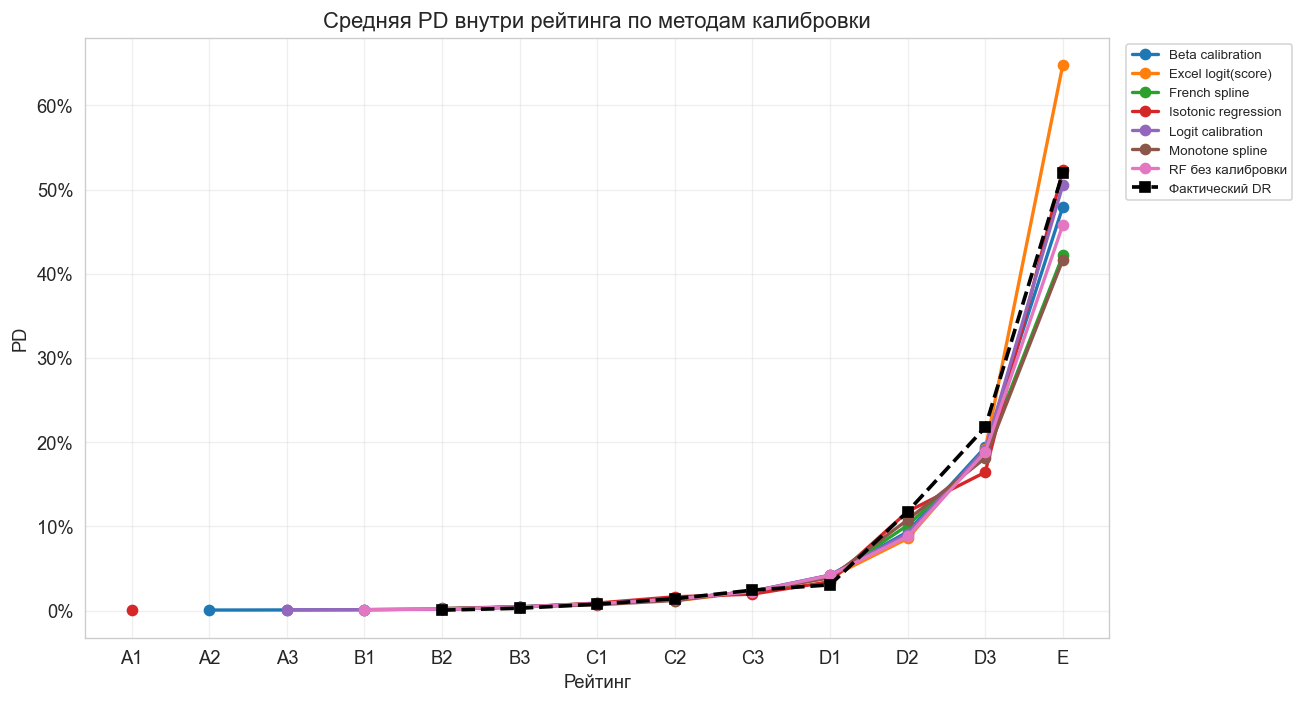

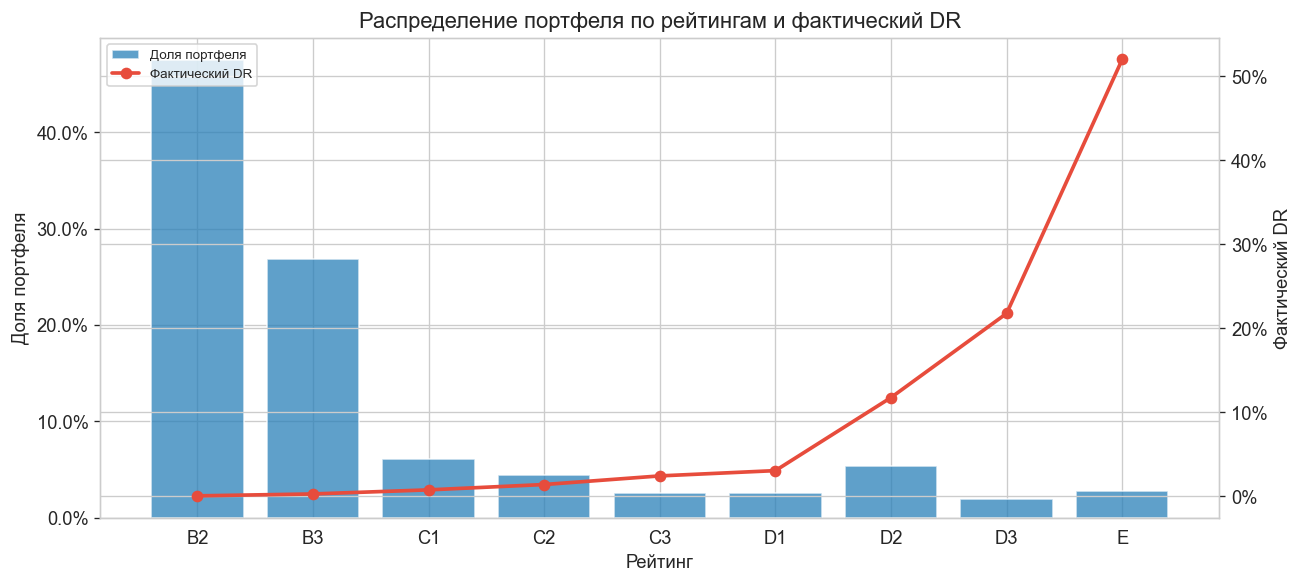

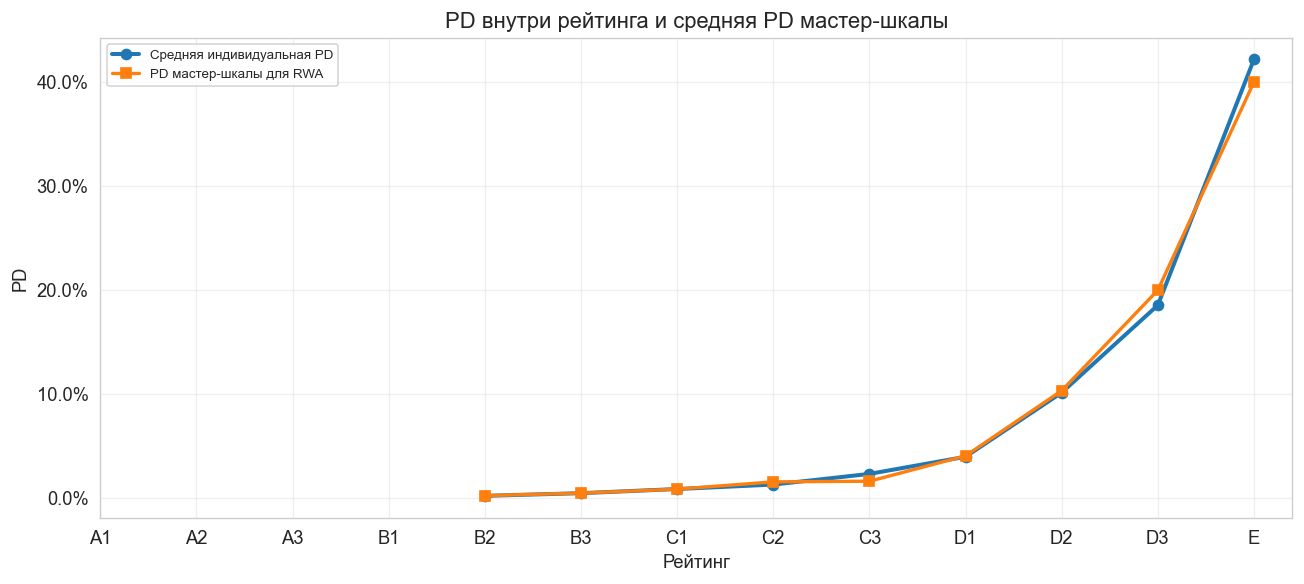

In [23]:
# =========================
# Мастер-шкала PD: сравнение методов по фиксированным PD-границам
# =========================

rating_pd_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="avg_pd")
    .reindex(MASTER_SCALE_RATINGS)
)

rating_structure = (
    master_scale_rwa_by_rating[master_scale_rwa_by_rating["method"] == master_scale_method]
    .set_index("rating")
    .reindex(MASTER_SCALE_RATINGS)
)

print(f"Структура портфеля для метода: {master_scale_method}")
display(
    rating_structure[[
        "n_assets",
        "portfolio_count_share",
        "observed_default_rate",
        "pd_min",
        "avg_pd",
        "pd_max",
        "pd_rating",
        "total_rwa",
        "rwa_share",
    ]]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "observed_default_rate": "{:.2%}",
        "pd_min": "{:.2%}",
        "avg_pd": "{:.2%}",
        "pd_max": "{:.2%}",
        "pd_rating": "{:.2%}",
        "total_rwa": "{:,.0f}",
        "rwa_share": "{:.1%}",
    })
)

print("Средняя индивидуальная PD внутри рейтинга по всем методам:")
display(
    rating_pd_matrix
    .style
    .format("{:.2%}")
    .background_gradient(axis=None, cmap="YlOrRd")
)

# График 1: средняя индивидуальная PD внутри рейтинга по методам.
fig, ax = plt.subplots(figsize=(11, 6))
for method in rating_pd_matrix.columns:
    ax.plot(
        rating_pd_matrix.index,
        rating_pd_matrix[method],
        marker="o",
        linewidth=2,
        label=method,
    )

ax.plot(
    rating_structure.index,
    rating_structure["observed_default_rate"],
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2.2,
    label="Фактический DR",
)

ax.set_title("Средняя PD внутри рейтинга по методам калибровки")
ax.set_xlabel("Рейтинг")
ax.set_ylabel("PD")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# График 2: неравномерное распределение портфеля по фиксированной мастер-шкале.
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(
    rating_structure.index,
    rating_structure["portfolio_count_share"],
    color=COLORS[1] if "COLORS" in globals() else None,
    alpha=0.75,
    label="Доля портфеля",
)

ax2 = ax.twinx()
ax2.plot(
    rating_structure.index,
    rating_structure["observed_default_rate"],
    color=COLORS[0] if "COLORS" in globals() else "black",
    marker="o",
    linewidth=2.2,
    label="Фактический DR",
)

ax.set_title("Распределение портфеля по рейтингам и фактический DR")
ax.set_xlabel("Рейтинг")
ax.set_ylabel("Доля портфеля")
ax2.set_ylabel("Фактический DR")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

# График 3: фактическая средняя PD в бакете против среднего значения мастер-шкалы.
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    rating_structure.index,
    rating_structure["avg_pd"],
    marker="o",
    linewidth=2.4,
    label="Средняя индивидуальная PD",
)
ax.plot(
    rating_structure.index,
    rating_structure["pd_rating"],
    marker="s",
    linewidth=2.0,
    label="PD мастер-шкалы для RWA",
)
ax.set_xticks(np.arange(len(rating_structure.index)))
ax.set_xticklabels(rating_structure.index)
ax.set_title("PD внутри рейтинга и средняя PD мастер-шкалы")
ax.set_xlabel("Рейтинг")
ax.set_ylabel("PD")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


каждое наблюдение OOT-портфеля → своя PD → распределение PD по методу

In [24]:
# =========================
# Calibration effect on EL, UL/RWA_capital and Capital_true under 845-P
# =========================

pred_map = {
    "RF raw": scores_test,
    **calibrated_probs,
}

capital_assumptions = IRBAssumptions(
    lgd=0.40,
    maturity_years=2.5,
    ead=1_000_000.0,
)

# Mentor-format 845-P calculation for every PD method on the same 2024 portfolio.
df_rwa = compare_845p_capital_by_method(
    pred_map,
    defaults=y_test.values.astype(float),
    assumptions=capital_assumptions,
    baseline_method="RF raw",
)

base_required_capital_rf = df_rwa.loc["RF raw", "total_required_capital"]

# Sensitivity proxy: RF capital divided by each method's UL/RWA_capital.
df_rwa["capital_proxy_if_keep_rf_capital"] = base_required_capital_rf / df_rwa["total_rwa"]
df_rwa["capital_proxy_uplift_vs_8pct"] = (
    df_rwa["capital_proxy_if_keep_rf_capital"] - capital_assumptions.capital_ratio
)

# Backward-compatible names for later summary cells.
df_rwa["h1_0_if_keep_rf_capital"] = df_rwa["capital_proxy_if_keep_rf_capital"]
df_rwa["h1_0_uplift_vs_norm"] = df_rwa["capital_proxy_uplift_vs_8pct"]

df_rwa = df_rwa.sort_values("total_required_capital")

print(f"Fixed EAD per observation = {capital_assumptions.ead:,.0f}")
print(f"LGD = {capital_assumptions.lgd:.0%}")
print(f"M = {capital_assumptions.maturity_years:.1f}")
print()
print("845-P calculation logic:")
print("EL / Reserves = PD * LGD * EAD")
print("UL / RWA_capital = EAD * LGD * (conditional PD - PD) * maturity adjustment")
print("Capital_true = Reserves + RWA_capital for non-defaulted observations")
print("Capital_true = LGD * EAD for defaulted observations")

# =========================
# Display table
# =========================

display_cols = [
    "avg_pd",
    "total_ead",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    "capital_saving_vs_baseline_pct",
    "capital_proxy_if_keep_rf_capital",
    "capital_proxy_uplift_vs_8pct",
]

df_rwa_display = df_rwa[display_cols].copy()

percent_cols = [
    "avg_pd",
    "rwa_saving_vs_baseline_pct",
    "capital_saving_vs_baseline_pct",
    "capital_proxy_if_keep_rf_capital",
    "capital_proxy_uplift_vs_8pct",
]

for col in percent_cols:
    df_rwa_display[col] = (100 * df_rwa_display[col]).round(2)

money_cols = [
    "total_ead",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_rwa",
    "total_required_capital",
]

for col in money_cols:
    df_rwa_display[col] = (df_rwa_display[col] / 1_000_000_000).round(3)

df_rwa_display = df_rwa_display.rename(columns={
    "avg_pd": "Avg PD, %",
    "total_ead": "EAD, bn",
    "total_expected_loss": "EL / Reserves, bn",
    "total_unexpected_loss_capital": "UL / RWA_capital, bn",
    "total_rwa": "RWA_capital, bn",
    "total_required_capital": "Capital_true, bn",
    "rwa_saving_vs_baseline_pct": "UL change vs RF, %",
    "capital_saving_vs_baseline_pct": "Capital change vs RF, %",
    "capital_proxy_if_keep_rf_capital": "Capital proxy with RF capital, %",
    "capital_proxy_uplift_vs_8pct": "Proxy uplift vs 8%, pp",
})

display(df_rwa_display)

print(f"First 3 rows of 845-P calculation for method: {list(calibrated_probs.keys())[-1]}")
mentor_check = calculate_845p_capital(
    calibrated_probs[list(calibrated_probs.keys())[-1]][:3],
    defaults=y_test.values.astype(float)[:3],
    assumptions=capital_assumptions,
)
display(mentor_check)


Fixed EAD per observation = 1,000,000
LGD = 40%
M = 2.5

845-P calculation logic:
EL / Reserves = PD * LGD * EAD
UL / RWA_capital = EAD * LGD * (conditional PD - PD) * maturity adjustment
Capital_true = Reserves + RWA_capital for non-defaulted observations
Capital_true = LGD * EAD for defaulted observations


,"Avg PD, %","EAD, bn","EL / Reserves, bn","UL / RWA_capital, bn","RWA_capital, bn","Capital_true, bn","UL change vs RF, %","Capital change vs RF, %","Capital proxy with RF capital, %","Proxy uplift vs 8%, pp"
method,,,,,,,,,,
Isotonic regression,2.85,6.372,0.073,0.273,0.273,0.367,14.51,9.70,149.25,141.25
Beta calibration,2.84,6.372,0.072,0.291,0.291,0.386,8.80,5.03,139.90,131.90
Logit calibration,2.84,6.372,0.072,0.307,0.307,0.403,3.78,1.02,132.61,124.61
RF raw,2.40,6.372,0.061,0.319,0.319,0.407,0.00,0.00,127.59,119.59
French spline,2.55,6.372,0.065,0.346,0.346,0.437,-8.54,-7.42,117.55,109.55
Monotone spline,2.52,6.372,0.064,0.373,0.373,0.464,-16.95,-14.06,109.10,101.10


First 3 rows of 845-P calculation for method: French spline


,FRAT_FINAL_PD,EAD,DEFAULT_DURING_NEXT_YEAR,Reserves,R,RWA_capital,Capital_true
0,0.001776,1000000.0,0.0,710.405780,0.229803,29244.009158,29954.414937
1,0.002030,1000000.0,0.0,811.837719,0.228420,31464.312963,32276.150682
2,0.001771,1000000.0,0.0,708.537700,0.229829,29201.458620,29909.996320


В данном блоке 8% трактуется как норматив достаточности капитала Н1.0, рассчитываемый по формуле `Н1.0 = капитал / RWA`. Поэтому RWA определяется как `UL capital / 8%`, то есть `UL capital × 12.5`. Показатель `required capital` равен `8% × RWA`, поэтому по конструкции совпадает с `UL capital`.

Показатель `Н1.0 при капитале RF` показывает, каким стал бы норматив достаточности капитала, если сохранить капитал, достаточный для RF без калибровки, но пересчитать RWA по каждому методу калибровки. Поэтому рост этого показателя отражает потенциальное высвобождение капитала за счет снижения RWA.

### Расчет по формуле 845-П в формате ментора

Ниже сохранен рекомендованный ментором блок расчета. Перед ним создается `data_ocp` с теми именами колонок, которые ожидает исходный код: `FRAT_FINAL_PD`, `EAD`, `DEFAULT_DURING_NEXT_YEAR`. В качестве `FRAT_FINAL_PD` используется финальная калиброванная PD-шкала из текущего эксперимента.

In [25]:
final_pd_method = list(calibrated_probs.keys())[-1]
print(f"Финальная PD для расчета 845-П: {final_pd_method}")

data_ocp = calculate_845p_capital(
    calibrated_probs[final_pd_method],
    defaults=y_test.values.astype(float),
    assumptions=capital_assumptions,
)

# Используем формулы из 845-П
data_ocp.head(3)

Финальная PD для расчета 845-П: French spline


,FRAT_FINAL_PD,EAD,DEFAULT_DURING_NEXT_YEAR,Reserves,R,RWA_capital,Capital_true
0,0.001776,1000000.0,0.0,710.405780,0.229803,29244.009158,29954.414937
1,0.002030,1000000.0,0.0,811.837719,0.228420,31464.312963,32276.150682
2,0.001771,1000000.0,0.0,708.537700,0.229829,29201.458620,29909.996320


### Ограничения RWA-блока

Расчет ниже нужен для оценки чувствительности капитала к калиброванной PD, а не для полноценной регуляторной отчетности.

Ключевые упрощения:

- используется Basel-style IRB формула для иллюстрации, а не полный production IRB контур банка;
- `EAD`, `LGD` и `M` фиксированы, чтобы изолировать именно эффект PD;
- не моделируются downturn LGD, CRM, guarantees, collateral, defaulted assets и сегментные регуляторные нюансы;
- синтетический портфель нужен для демонстрации методологии, а не для оценки реального банка.

Поэтому результаты RWA следует читать как **сравнительный эффект калибровки**, а не как абсолютный норматив капитала.

#### Визуализация эффекта на RWA и капитал

Ниже показано, как различия в калиброванной `PD` отражаются на:
- резервах;
- имплицитном `RWA`;
- требуемом капитале при `H1 = 8%`;
- экономии капитала относительно сырых `PD`;
- значении `H1`, если сохранить капитал, достаточный для ванильной модели.

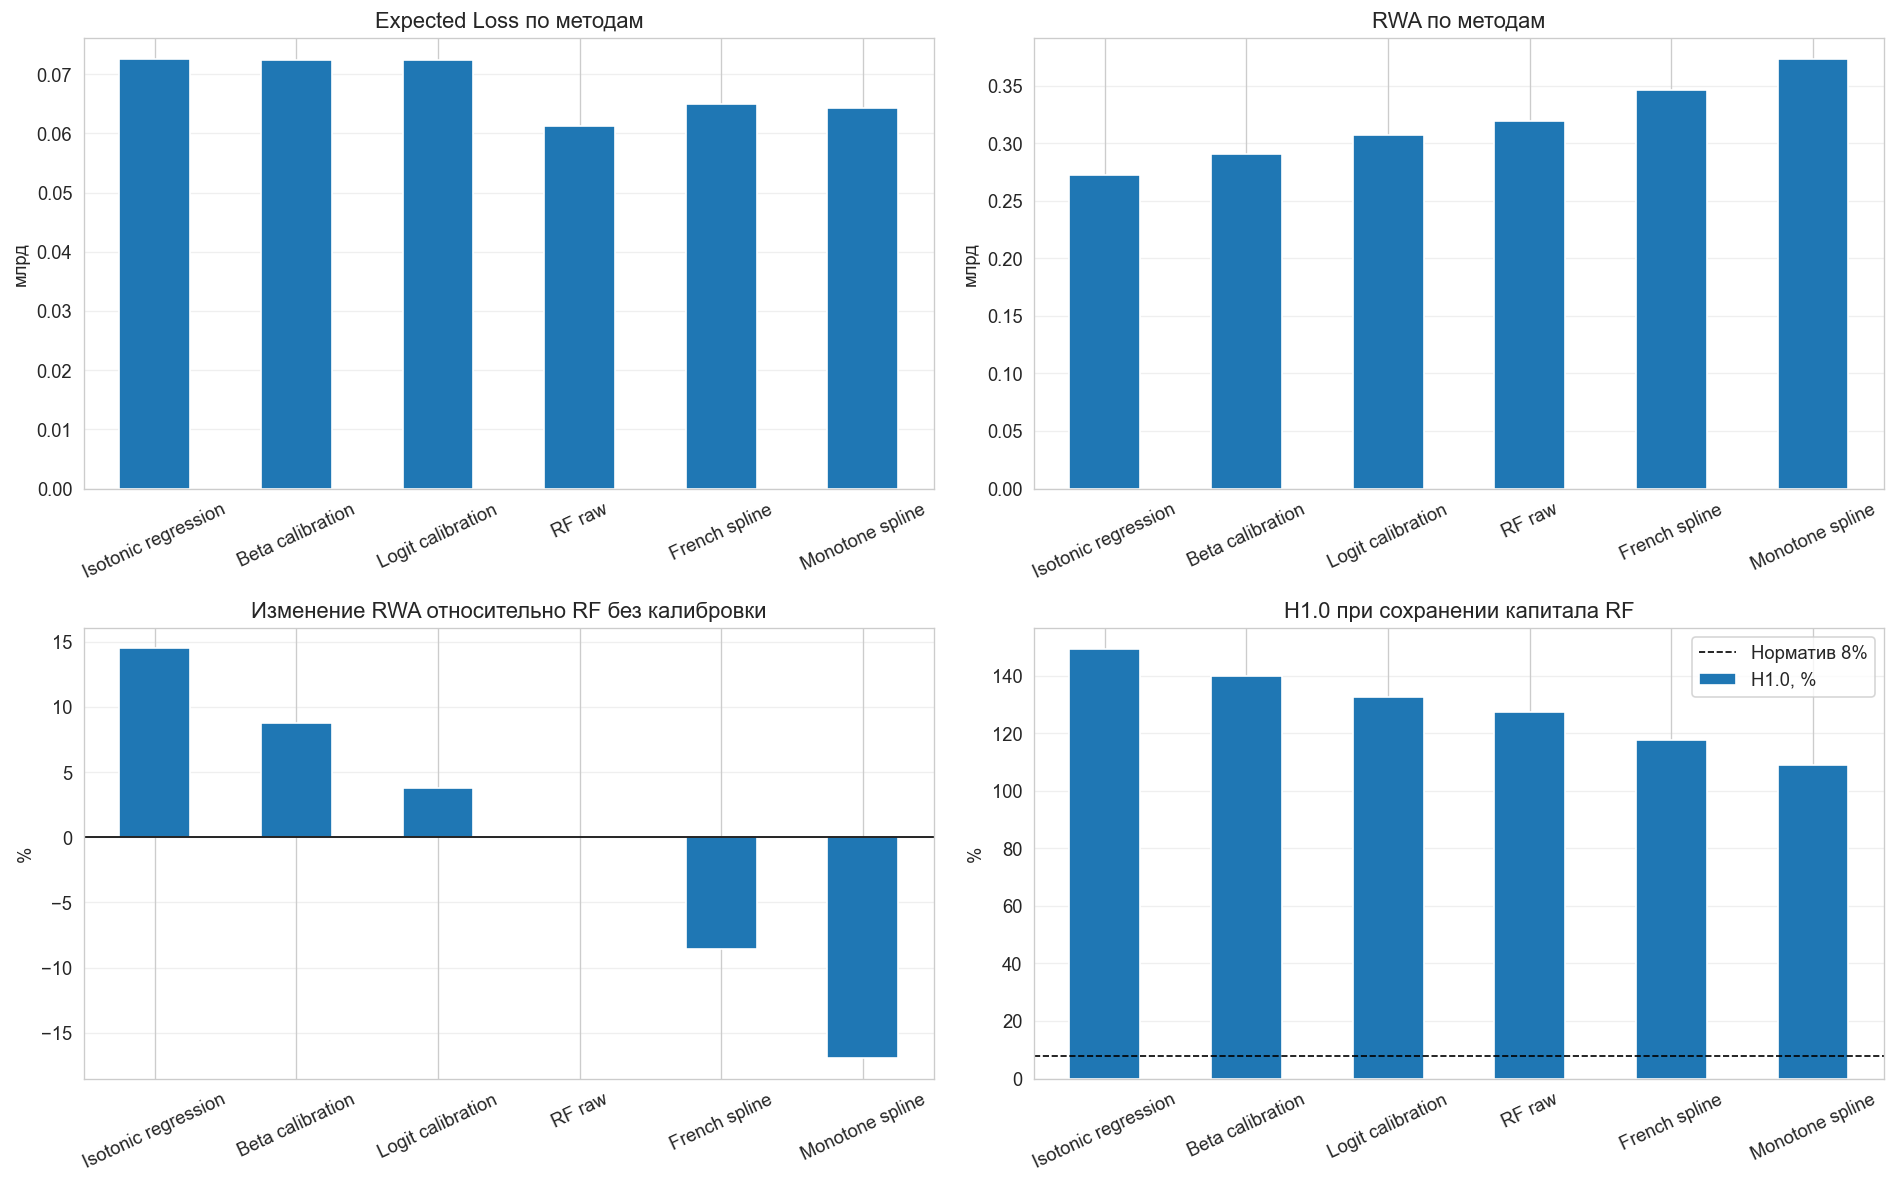

In [26]:
# =========================
# Компактная визуализация capital impact
# =========================

plot_df = df_rwa.reset_index().copy()

plot_df["EL, млрд"] = plot_df["total_expected_loss"] / 1_000_000_000
plot_df["RWA, млрд"] = plot_df["total_rwa"] / 1_000_000_000
plot_df["Изм. RWA vs RF, %"] = 100 * plot_df["rwa_saving_vs_baseline_pct"]
plot_df["Н1.0, %"] = 100 * plot_df["h1_0_if_keep_rf_capital"]

# Если хочешь дополнительно видеть риск-вес портфеля:
plot_df["RWA / EAD, %"] = 100 * (plot_df["total_rwa"] / plot_df["total_ead"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Expected Loss
plot_df.plot(
    x="method",
    y="EL, млрд",
    kind="bar",
    ax=axes[0, 0],
    legend=False,
    rot=25,
    title="Expected Loss по методам"
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("млрд")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. RWA
plot_df.plot(
    x="method",
    y="RWA, млрд",
    kind="bar",
    ax=axes[0, 1],
    legend=False,
    rot=25,
    title="RWA по методам"
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("млрд")
axes[0, 1].grid(axis="y", alpha=0.3)

# 3. Изменение RWA vs RF
plot_df.plot(
    x="method",
    y="Изм. RWA vs RF, %",
    kind="bar",
    ax=axes[1, 0],
    legend=False,
    rot=25,
    title="Изменение RWA относительно RF без калибровки"
)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("%")
axes[1, 0].grid(axis="y", alpha=0.3)

# 4. Н1.0 при сохранении капитала RF
plot_df.plot(
    x="method",
    y="Н1.0, %",
    kind="bar",
    ax=axes[1, 1],
    legend=False,
    rot=25,
    title="Н1.0 при сохранении капитала RF"
)
axes[1, 1].axhline(
    100 * capital_assumptions.capital_ratio,
    color="black",
    lw=1,
    linestyle="--",
    label="Норматив 8%"
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("%")
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7. Оценка устойчивости результатов

При близких значениях метрик точечные оценки сами по себе могут вводить в заблуждение. Поэтому устойчивость результатов проверяется через **bootstrap confidence intervals** для Brier Score и AUC.

Если доверительные интервалы методов существенно перекрываются, это означает, что различия между ними малы и не дают оснований объявлять одного явного победителя только по одной точечной метрике.

In [27]:
from sklearn.metrics import roc_auc_score

boot_rows = []

print("Bootstrap 95% CI (1000 итераций) на OOT Test...")
print(f"{'Метод':<28} {'Brier':>7}  {'95% CI Brier':>18}  {'AUC':>7}  {'95% CI AUC':>18}")
print("-" * 85)

for name, probs in all_preds.items():
    ci_brier = bootstrap_ci(y_test.values, probs, brier_score,   n_iter=1000, random_state=42)
    ci_auc   = bootstrap_ci(y_test.values, probs, roc_auc_score, n_iter=1000, random_state=42)

    boot_rows.append({
        "method": name,
        "brier_point": ci_brier["point_estimate"],
        "brier_ci_lower": ci_brier["ci_lower"],
        "brier_ci_upper": ci_brier["ci_upper"],
        "auc_point": ci_auc["point_estimate"],
        "auc_ci_lower": ci_auc["ci_lower"],
        "auc_ci_upper": ci_auc["ci_upper"],
    })

    print(
        f"{name:<28} "
        f"{ci_brier['point_estimate']:>7.5f}  "
        f"[{ci_brier['ci_lower']:.5f}, {ci_brier['ci_upper']:.5f}]  "
        f"{ci_auc['point_estimate']:>7.4f}  "
        f"[{ci_auc['ci_lower']:.4f}, {ci_auc['ci_upper']:.4f}]"
    )

df_boot = pd.DataFrame(boot_rows).set_index("method")

print("\nИнтерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.")


Bootstrap 95% CI (1000 итераций) на OOT Test...
Метод                          Brier        95% CI Brier      AUC          95% CI AUC
-------------------------------------------------------------------------------------


RF без калибровки            0.01907  [0.01664, 0.02149]   0.9545  [0.9394, 0.9675]


Logit calibration            0.01881  [0.01642, 0.02125]   0.9545  [0.9394, 0.9675]


Isotonic regression          0.01822  [0.01588, 0.02054]   0.9576  [0.9442, 0.9692]


Beta calibration             0.01878  [0.01644, 0.02122]   0.9545  [0.9394, 0.9675]


Monotone spline              0.01941  [0.01701, 0.02188]   0.9542  [0.9390, 0.9671]


French spline                0.01923  [0.01684, 0.02162]   0.9543  [0.9393, 0.9674]

Интерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.


### Анализ по полной шкале вероятностей

Ниже калибровка и распределение PD показаны **на всей шкале [0; 1]**, а не только в той области, где сосредоточена основная масса наблюдений.  
Дополнительно для каждого метода строится таблица фиксированных биннов `[0.0–0.1], …, [0.9–1.0]`, чтобы увидеть, **как именно модель распределяет наблюдения и дефолты по всей шкале риска**.


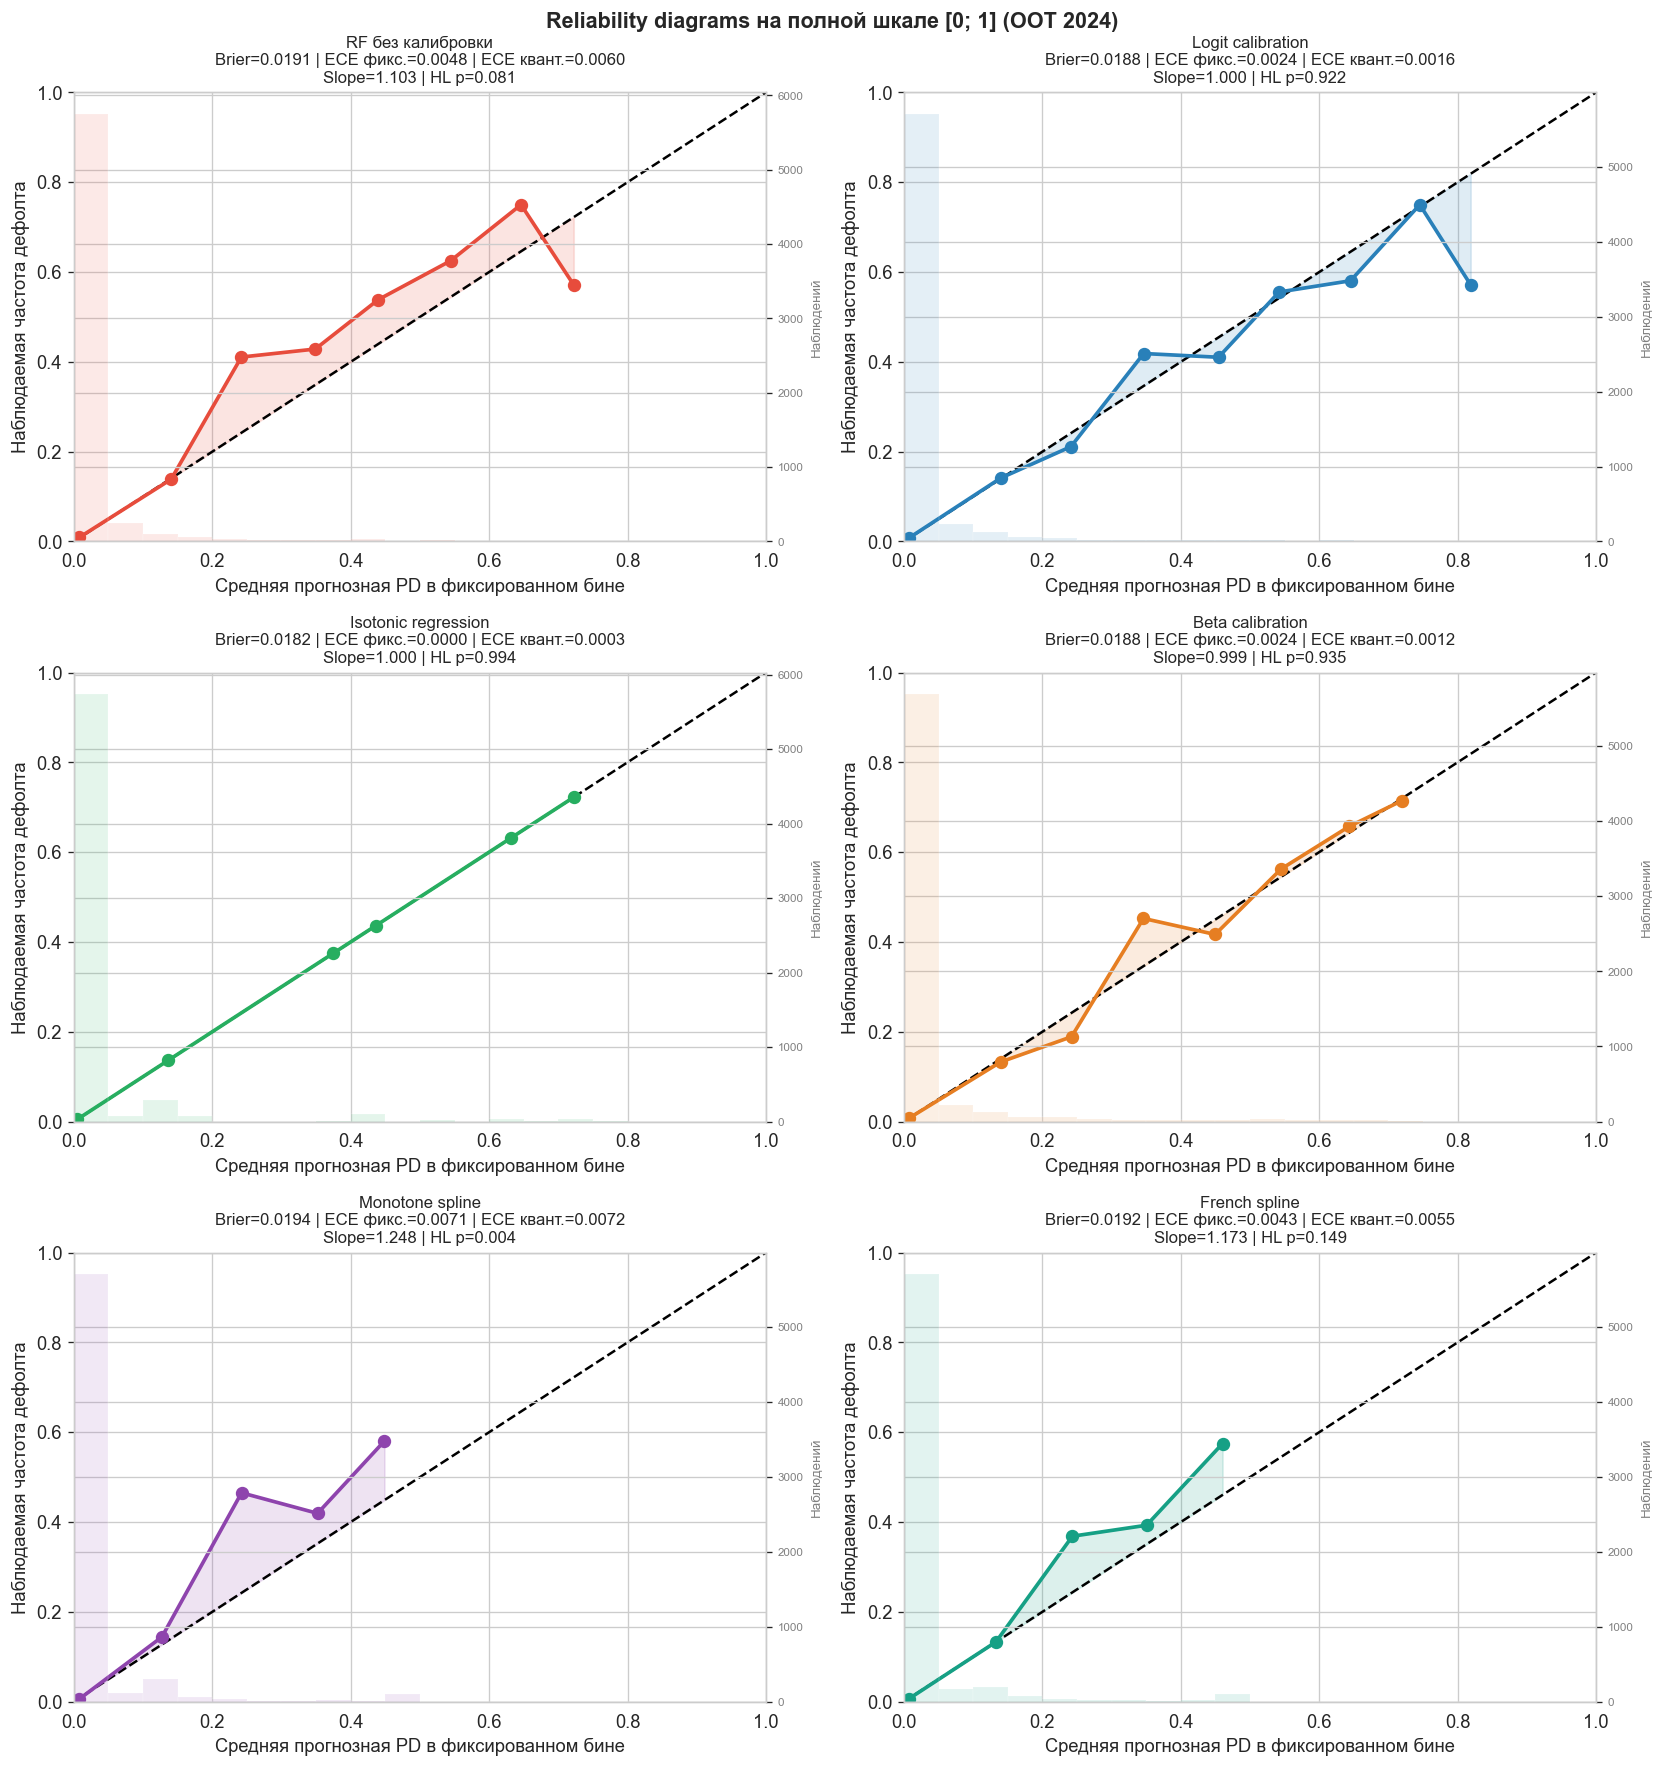

Распределение наблюдений и дефолтов по фиксированным бинам на полной шкале [0; 1]:

RF без калибровки
          bin    n  share  avg_pd  default_rate  defaults
(-0.001, 0.1] 6003  94.21  0.0078        0.0090        54
   (0.1, 0.2]  166   2.61  0.1406        0.1386        23
   (0.2, 0.3]   56   0.88  0.2421        0.4107        23
   (0.3, 0.4]   49   0.77  0.3489        0.4286        21
   (0.4, 0.5]   39   0.61  0.4398        0.5385        21
   (0.5, 0.6]   32   0.50  0.5442        0.6250        20
   (0.6, 0.7]   20   0.31  0.6461        0.7500        15
   (0.7, 0.8]    7   0.11  0.7222        0.5714         4
   (0.8, 0.9]    0   0.00  0.0000        0.0000         0
   (0.9, 1.0]    0   0.00  0.0000        0.0000         0

Logit calibration
          bin    n  share  avg_pd  default_rate  defaults
(-0.001, 0.1] 5937  93.17  0.0071        0.0077        46
   (0.1, 0.2]  184   2.89  0.1399        0.1413        26
   (0.2, 0.3]   71   1.11  0.2413        0.2113        15
   (0.3, 

In [28]:
all_methods = {"RF без калибровки": scores_test, **calibrated_probs}

n_methods = len(all_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (name, probs) in enumerate(all_methods.items()):
    ax = axes[i]
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10, strategy="uniform")
    m = summary_metrics(y_test.values, probs)

    ax.plot([0, 1], [0, 1], "k--", lw=1.5)
    ax.plot(mean_pred, frac_pos, "o-", color=COLORS[i], lw=2.2, ms=7)
    ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.15, color=COLORS[i])

    ax2 = ax.twinx()
    ax2.hist(probs, bins=np.linspace(0, 1, 21), alpha=0.12, color=COLORS[i])
    ax2.set_ylabel("Наблюдений", fontsize=8, color="gray")
    ax2.tick_params(axis="y", labelsize=7, labelcolor="gray")

    subtitle = (
        f'Brier={m["brier_score"]:.4f} | ECE фикс.={m["ece_uniform"]:.4f} | ECE квант.={m["ece_quantile"]:.4f}\n'
        f'Slope={m["cal_slope"]:.3f} | HL p={m["hl_p_value"]:.3f}'
    )
    ax.set_title(f"{name}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Средняя прогнозная PD в фиксированном бине")
    ax.set_ylabel("Наблюдаемая частота дефолта")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Reliability diagrams на полной шкале [0; 1] (OOT 2024)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Распределение наблюдений и дефолтов по фиксированным бинам на полной шкале [0; 1]:")
for name, probs in all_methods.items():
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)
    bin_table = fixed_bin_table(y_test.values, probs, n_bins=10).copy()
    bin_table["share"] = (100 * bin_table["share"]).round(2)
    bin_table["avg_pd"] = bin_table["avg_pd"].round(4)
    bin_table["default_rate"] = bin_table["default_rate"].round(4)
    print(bin_table.to_string(index=False))

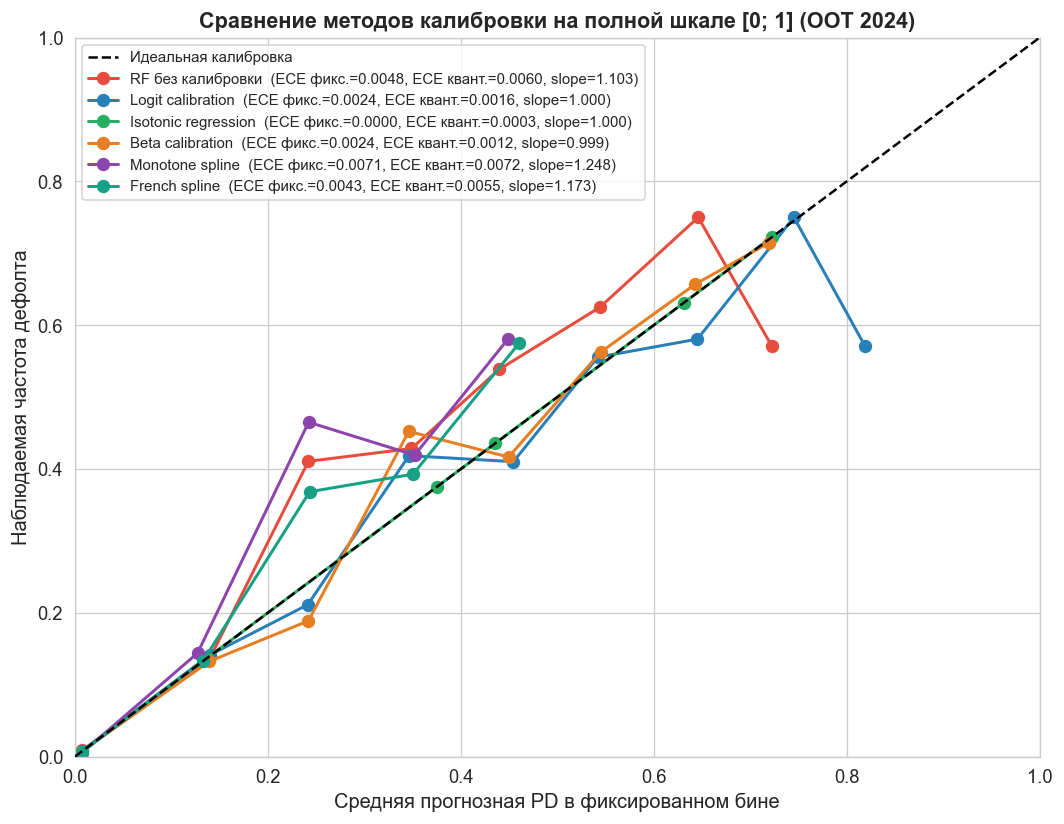

In [29]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка", zorder=5)

for (name, probs), color in zip(all_methods.items(), COLORS):
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10, strategy="uniform")
    m = summary_metrics(y_test.values, probs)
    lw = 3.0 if "сплайн" in name.lower() else 1.8
    label = f"{name}  (ECE фикс.={m['ece_uniform']:.4f}, ECE квант.={m['ece_quantile']:.4f}, slope={m['cal_slope']:.3f})"
    ax.plot(mean_pred, frac_pos, "o-", color=color, lw=lw, ms=7, label=label)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Средняя прогнозная PD в фиксированном бине", fontsize=12)
ax.set_ylabel("Наблюдаемая частота дефолта", fontsize=12)
ax.set_title("Сравнение методов калибровки на полной шкале [0; 1] (OOT 2024)", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### Вогнутая функция совокупного капитала под кредитный риск

В данном блоке для каждого метода калибровки строится зависимость между вероятностью дефолта `PD` и отношением капитала к `EAD`. Совокупный капитал разбивается на две части:

- `K_EL = EL / EAD` — ожидаемые потери как доля от экспозиции;
- `K_UL = UL capital / EAD` — капитал под неожиданные потери как доля от экспозиции.

Суммарная кривая `K_EL + K_UL` показывает, как изменение PD влияет на резервирование и капитальную нагрузку. Отдельные графики строятся по каждому методу калибровки, а общий график позволяет сопоставить итоговую капитальную кривую между методами.

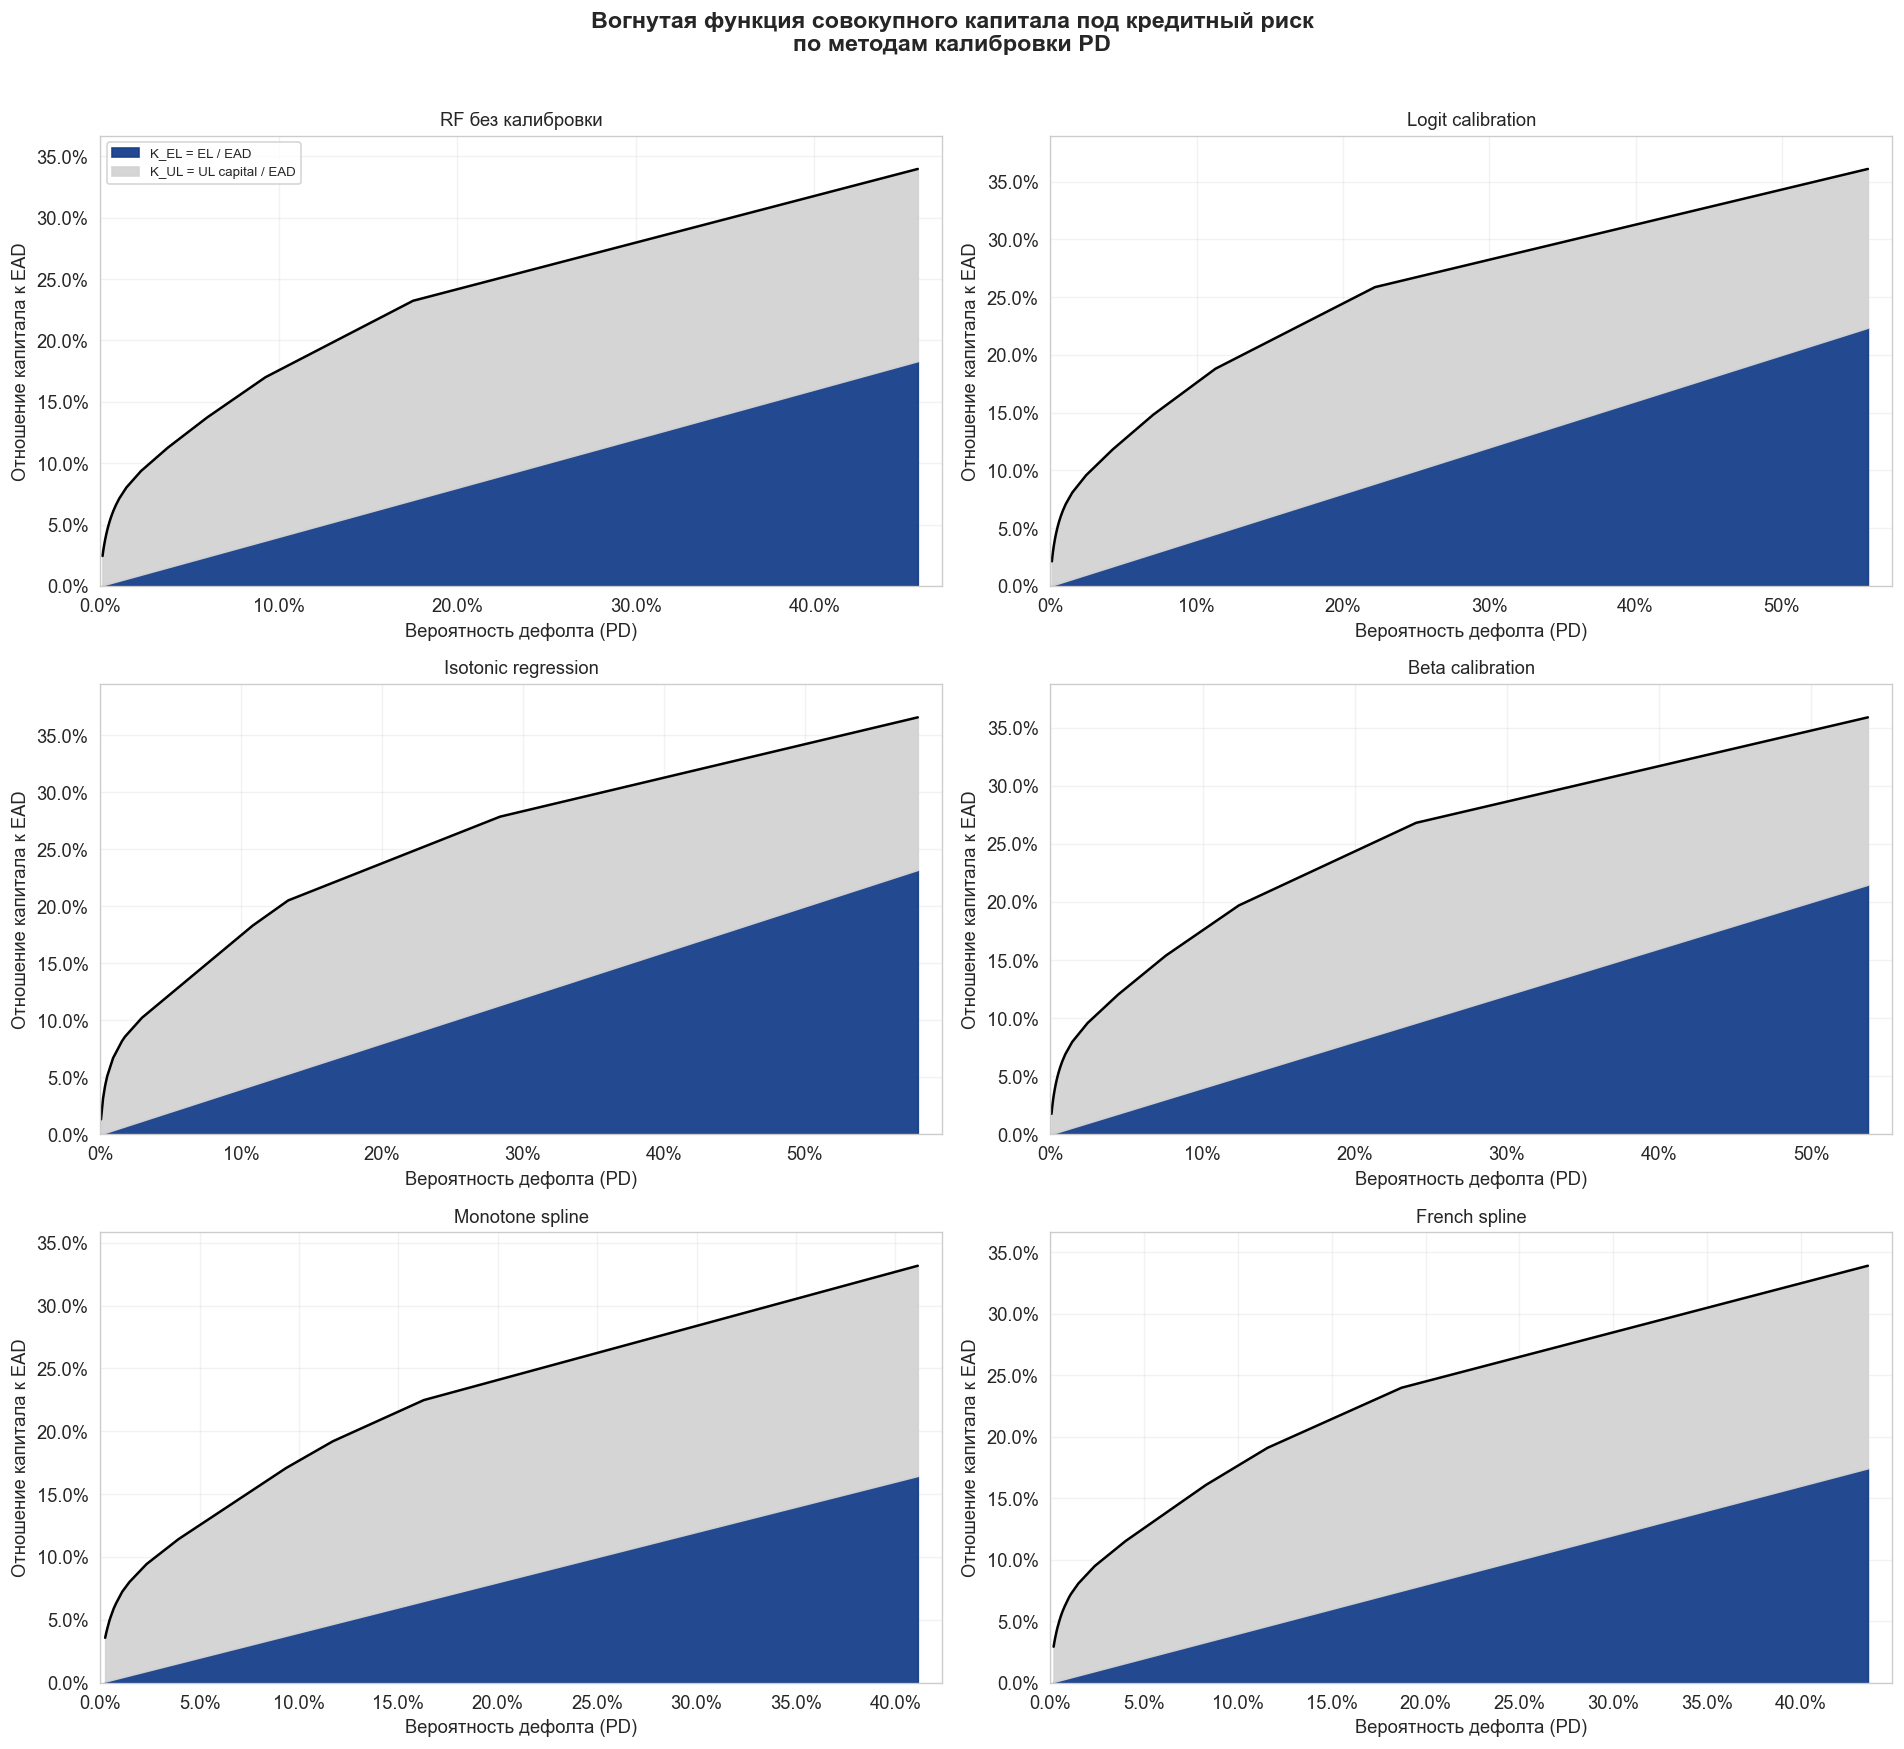

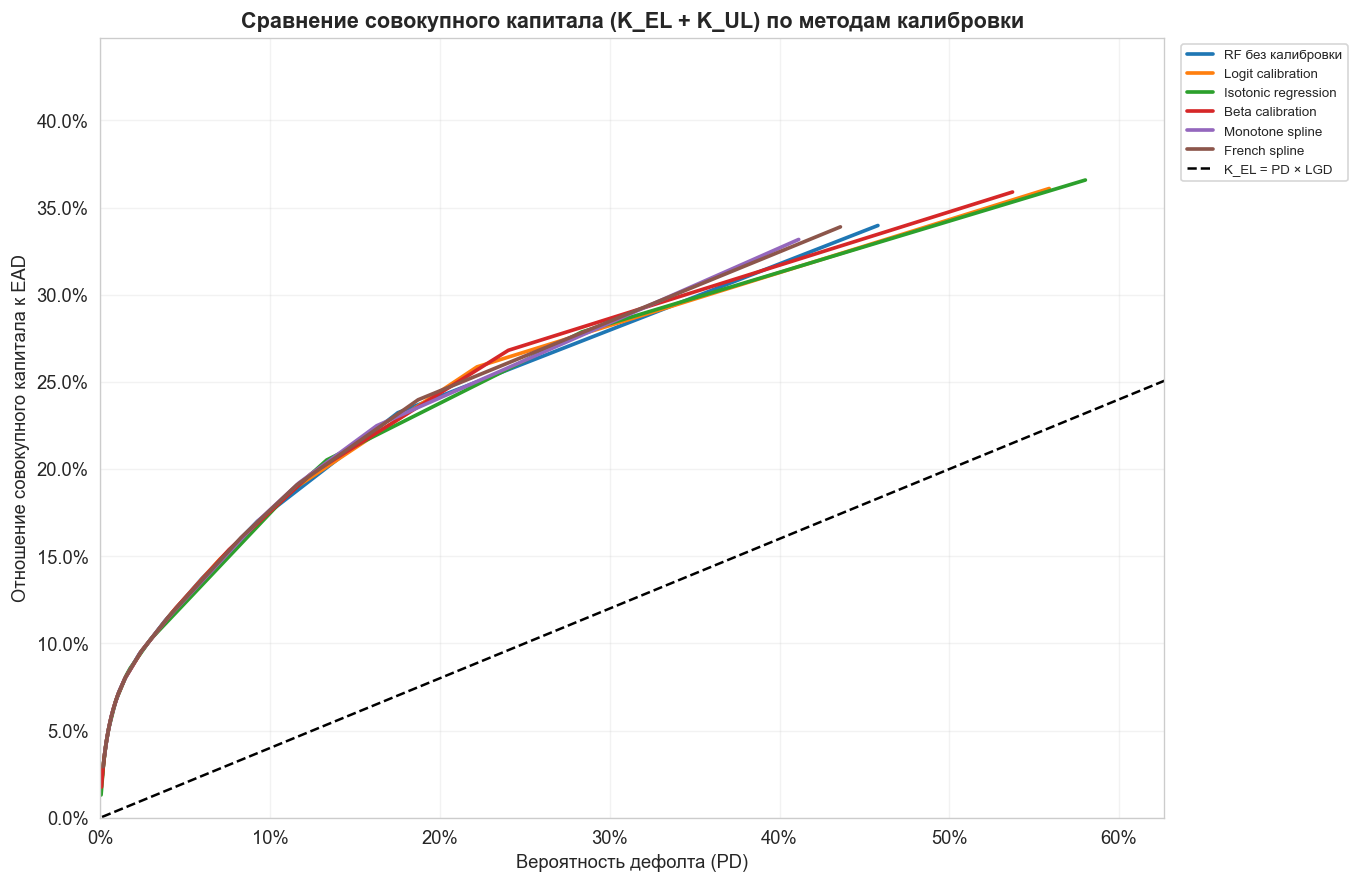

,avg_pd,avg_k_el_ratio,avg_k_ul_ratio,avg_k_total_ratio,max_pd
method,,,,,
RF без калибровки,2.40%,0.96%,5.00%,5.97%,74.36%
Logit calibration,2.84%,1.14%,4.82%,5.95%,83.61%
Isotonic regression,2.85%,1.14%,4.28%,5.42%,75.00%
Beta calibration,2.84%,1.14%,4.56%,5.70%,74.56%
Monotone spline,2.52%,1.01%,5.85%,6.86%,45.31%
French spline,2.55%,1.02%,5.43%,6.45%,46.81%


In [30]:
# =========================
# Вогнутая функция совокупного капитала под кредитный риск
# Для каждого метода калибровки + общий график
# =========================

capital_curve_methods = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

def build_capital_curve(pd_values, assumptions, n_bins=40):
    """
    Строит сглаженную эмпирическую кривую:
    PD -> K_EL/EAD, K_UL/EAD, K_total/EAD
    
    n_bins: число квантильных бинов для сглаживания.
    """
    pd_values = np.clip(np.asarray(pd_values, dtype=float), 1e-6, 1 - 1e-6)
    pd_values = np.sort(pd_values)

    tmp = calculate_irb_capital(pd_values, assumptions=assumptions).copy()
    tmp["k_el_ratio"] = tmp["expected_loss"] / tmp["ead"]
    tmp["k_ul_ratio"] = tmp["unexpected_loss_capital"] / tmp["ead"]
    tmp["k_total_ratio"] = tmp["k_el_ratio"] + tmp["k_ul_ratio"]

    # Сглаживание через квантильные бины
    if n_bins is not None and len(tmp) > n_bins:
        tmp["pd_bin"] = pd.qcut(tmp["pd"], q=n_bins, duplicates="drop")
        curve = (
            tmp.groupby("pd_bin", observed=True)
            .agg(
                pd=("pd", "mean"),
                k_el_ratio=("k_el_ratio", "mean"),
                k_ul_ratio=("k_ul_ratio", "mean"),
                k_total_ratio=("k_total_ratio", "mean"),
                n=("pd", "size"),
            )
            .reset_index(drop=True)
            .sort_values("pd")
        )
    else:
        curve = tmp[["pd", "k_el_ratio", "k_ul_ratio", "k_total_ratio"]].copy()

    return curve


# -------------------------
# 1. Индивидуальные графики для каждого метода
# -------------------------
n_methods = len(capital_curve_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (method, probs) in enumerate(capital_curve_methods.items()):
    ax = axes[i]
    curve = build_capital_curve(probs, capital_assumptions, n_bins=40)

    # Нижняя часть: K_EL
    ax.fill_between(
        curve["pd"],
        0,
        curve["k_el_ratio"],
        color="#173f8a",
        alpha=0.95,
        label="K_EL = EL / EAD",
    )

    # Верхняя часть: K_UL
    ax.fill_between(
        curve["pd"],
        curve["k_el_ratio"],
        curve["k_total_ratio"],
        color="lightgray",
        alpha=0.95,
        label="K_UL = UL capital / EAD",
    )

    # Граница суммарного капитала
    ax.plot(
        curve["pd"],
        curve["k_total_ratio"],
        color="black",
        linewidth=1.5,
    )

    ax.set_title(method, fontsize=11)
    ax.set_xlabel("Вероятность дефолта (PD)")
    ax.set_ylabel("Отношение капитала к EAD")
    ax.set_xlim(0, min(1.0, curve["pd"].max() * 1.03))
    ax.set_ylim(0, max(0.35, curve["k_total_ratio"].max() * 1.08))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(True, alpha=0.25)

    if i == 0:
        ax.legend(fontsize=8, loc="upper left")

# убрать пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Вогнутая функция совокупного капитала под кредитный риск\n"
    "по методам калибровки PD",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()


# -------------------------
# 2. Общий график: сравнение суммарной кривой капитала
# -------------------------
capital_curves = {
    method: build_capital_curve(probs, capital_assumptions, n_bins=40)
    for method, probs in capital_curve_methods.items()
}

max_curve_pd = max(float(curve["pd"].max()) for curve in capital_curves.values())
max_curve_capital = max(float(curve["k_total_ratio"].max()) for curve in capital_curves.values())

pd_grid = np.linspace(0.001, max(0.999, max_curve_pd), 300)
k_el_grid = pd_grid * capital_assumptions.lgd
max_reference_capital = float(k_el_grid.max())

fig, ax = plt.subplots(figsize=(14, 7.5))

for method, curve in capital_curves.items():
    ax.plot(
        curve["pd"],
        curve["k_total_ratio"],
        linewidth=2.2,
        label=method,
    )

# Для ориентира: ожидаемые потери без UL capital. 
ax.plot(
    pd_grid,
    k_el_grid,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="K_EL = PD × LGD",
)

ax.set_title(
    "Сравнение совокупного капитала (K_EL + K_UL) по методам калибровки",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Вероятность дефолта (PD)")
ax.set_ylabel("Отношение совокупного капитала к EAD")
ax.set_xlim(0, min(1.0, max_curve_pd * 1.08))
ax.set_ylim(0, max(max_curve_capital, max_reference_capital) * 1.12)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


# -------------------------
# 3. Таблица-резюме по среднему уровню капитала
# -------------------------
capital_curve_summary = []

for method, probs in capital_curve_methods.items():
    tmp = calculate_irb_capital(probs, assumptions=capital_assumptions).copy()

    capital_curve_summary.append({
        "method": method,
        "avg_pd": np.mean(tmp["pd"]),
        "avg_k_el_ratio": np.mean(tmp["expected_loss"] / tmp["ead"]),
        "avg_k_ul_ratio": np.mean(tmp["unexpected_loss_capital"] / tmp["ead"]),
        "avg_k_total_ratio": np.mean(
            (tmp["expected_loss"] + tmp["unexpected_loss_capital"]) / tmp["ead"]
        ),
        "max_pd": np.max(tmp["pd"]),
    })

capital_curve_summary = pd.DataFrame(capital_curve_summary).set_index("method")

display(
    capital_curve_summary.style.format({
        "avg_pd": "{:.2%}",
        "avg_k_el_ratio": "{:.2%}",
        "avg_k_ul_ratio": "{:.2%}",
        "avg_k_total_ratio": "{:.2%}",
        "max_pd": "{:.2%}",
    })
)

## 8. Выводы, практическая интерпретация и ограничения

In [31]:
print("=" * 90)
print("ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD")
print("=" * 90)

# =========================
# 1. Компактная таблица статистических метрик
# =========================

metric_cols = [
    "brier_score",
    "log_loss",
    "ece_uniform",
    "ece_quantile",
    "hl_p_value",
    "cal_slope",
    "cal_intercept",
]

df_metrics_final = (
    df_results[metric_cols]
    .sort_values(["brier_score", "log_loss", "ece_quantile"])
    .copy()
)

display(
    df_metrics_final.style.format({
        "brier_score": "{:.5f}",
        "log_loss": "{:.5f}",
        "ece_uniform": "{:.5f}",
        "ece_quantile": "{:.5f}",
        "hl_p_value": "{:.3f}",
        "cal_slope": "{:.3f}",
        "cal_intercept": "{:.3f}",
    })
)


# =========================
# 2. Компактная таблица backtesting expected defaults
# =========================

if "method_summary" in globals():
    df_backtest_final = method_summary[[
        "avg_pd",
        "defaults",
        "expected_defaults",
        "default_gap",
        "calibration_ratio",
    ]].copy()

    df_backtest_final["abs_default_gap"] = df_backtest_final["default_gap"].abs()

    display(
        df_backtest_final
        .sort_values("abs_default_gap")
        .style.format({
            "avg_pd": "{:.2%}",
            "defaults": "{:.0f}",
            "expected_defaults": "{:.2f}",
            "default_gap": "{:.2f}",
            "calibration_ratio": "{:.2f}",
            "abs_default_gap": "{:.2f}",
        })
    )


# =========================
# 3. Компактная таблица capital impact
# =========================

h1_col = (
    "h1_0_if_keep_rf_capital"
    if "h1_0_if_keep_rf_capital" in df_rwa.columns
    else "h1_if_keep_raw_capital"
)

df_capital_final = df_rwa[[
    "avg_pd",
    "total_expected_loss",
    "total_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    h1_col,
]].copy()

df_capital_final["total_expected_loss"] = df_capital_final["total_expected_loss"] / 1_000_000_000
df_capital_final["total_rwa"] = df_capital_final["total_rwa"] / 1_000_000_000
df_capital_final["total_required_capital"] = df_capital_final["total_required_capital"] / 1_000_000_000

df_capital_final = df_capital_final.rename(columns={
    "avg_pd": "Средняя PD",
    "total_expected_loss": "EL / Reserves, млрд",
    "total_rwa": "RWA, млрд",
    "total_required_capital": "Требуемый капитал, млрд",
    "rwa_saving_vs_baseline_pct": "Снижение RWA vs RF",
    h1_col: "Н1.0 при капитале RF",
})

display(
    df_capital_final
    .sort_values("RWA, млрд")
    .style.format({
        "Средняя PD": "{:.2%}",
        "EL / Reserves, млрд": "{:.3f}",
        "RWA, млрд": "{:.3f}",
        "Требуемый капитал, млрд": "{:.3f}",
        "Снижение RWA vs RF": "{:.2%}",
        "Н1.0 при капитале RF": "{:.2%}",
    })
)


# =========================
# 4. Автоматическое определение лучших методов по критериям
# =========================

best_brier = df_results["brier_score"].idxmin()
best_logloss = df_results["log_loss"].idxmin()
best_ece = df_results["ece_quantile"].idxmin()
best_rwa = df_rwa["total_rwa"].idxmin()
best_capital = df_rwa["total_required_capital"].idxmin()

if "method_summary" in globals():
    best_backtest = method_summary["default_gap"].abs().idxmin()
else:
    best_backtest = "не рассчитано"

summary_table = pd.DataFrame([
    {
        "Критерий": "Минимальный Brier Score",
        "Лучший метод": best_brier,
        "Значение": f"{df_results.loc[best_brier, 'brier_score']:.5f}",
        "Интерпретация": "Лучшее среднее качество вероятностного прогноза.",
    },
    {
        "Критерий": "Минимальный Log-Loss",
        "Лучший метод": best_logloss,
        "Значение": f"{df_results.loc[best_logloss, 'log_loss']:.5f}",
        "Интерпретация": "Наиболее сильный результат с учетом штрафа за уверенные ошибки.",
    },
    {
        "Критерий": "Минимальный ECE на квантильных бинах",
        "Лучший метод": best_ece,
        "Значение": f"{df_results.loc[best_ece, 'ece_quantile']:.5f}",
        "Интерпретация": "Лучшее совпадение прогнозных PD с фактическими дефолтами по группам риска.",
    },
    {
        "Критерий": "Минимальная ошибка expected defaults",
        "Лучший метод": best_backtest,
        "Значение": (
            f"{method_summary.loc[best_backtest, 'default_gap']:.2f}"
            if "method_summary" in globals()
            else "—"
        ),
        "Интерпретация": "Лучшее совпадение с фактическим числом дефолтов на OOT.",
    },
    {
        "Критерий": "Минимальный RWA",
        "Лучший метод": best_rwa,
        "Значение": f"{df_rwa.loc[best_rwa, 'total_rwa'] / 1_000_000_000:.3f} млрд",
        "Интерпретация": "Наименьшая капитальная нагрузка по IRB-style расчету.",
    },
    {
        "Критерий": "Минимальный требуемый капитал",
        "Лучший метод": best_capital,
        "Значение": f"{df_rwa.loc[best_capital, 'total_required_capital'] / 1_000_000_000:.3f} млрд",
        "Интерпретация": "Минимальный капитал при нормативе Н1.0 = 8%.",
    },
])

display(summary_table)


# =========================
# 5. Итоговый текстовый вывод
# =========================

print("\n" + "=" * 90)
print("ИТОГОВЫЙ ВЫВОД")
print("=" * 90)

print(
    "1. Единого лучшего метода калибровки нет: разные методы выигрывают по разным критериям. "
    "Поэтому выбор метода нельзя делать только по одной метрике."
)

print(
    f"2. По статистическим метрикам лучшие результаты дают: "
    f"Brier Score — {best_brier}, Log-Loss — {best_logloss}, ECE — {best_ece}."
)

if "method_summary" in globals():
    print(
        f"3. По агрегированному backtesting expected defaults лучший результат показывает: {best_backtest}. "
        "Это важно, потому что метод с хорошими Brier / Log-Loss не обязательно лучше попадает "
        "в фактическое число дефолтов портфеля."
    )

print(
    f"4. Минимальный RWA дает: {best_rwa}; минимальный требуемый капитал дает: {best_capital}. "
    "Однако снижение капитала нельзя трактовать как автоматическое улучшение модели, "
    "если одновременно ухудшается совпадение с фактическими дефолтами."
)

print(
    "5. Метрики ранжирования AUC / Gini / KS почти не меняются после калибровки, "
    "поскольку калибраторы в основном сохраняют порядок заемщиков и меняют именно уровень PD."
)

print(
    f"6. Rating Master Scale A1...E является отдельным уровнем анализа: все методы приводятся "
    f"к целевой CT calibration-периода ({TARGET_CT:.2%}), поэтому в этом блоке сравнивается "
    "не общий уровень expected defaults, а форма рейтинговой PD-кривой."
)

print(
    "7. Для итоговой интерпретации наиболее корректно сопоставлять сразу три блока: "
    "статистические метрики PD, backtesting expected defaults и влияние на RWA / Н1.0."
)

ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD


,brier_score,log_loss,ece_uniform,ece_quantile,hl_p_value,cal_slope,cal_intercept
method,,,,,,,
Isotonic regression,0.01822,0.06576,0.00000,0.00031,0.994,1.000,-0.001
Beta calibration,0.01878,0.06809,0.00242,0.00119,0.935,0.999,-0.001
Logit calibration,0.01881,0.06827,0.00238,0.00156,0.922,1.000,0.000
RF без калибровки,0.01907,0.06911,0.00480,0.00599,0.081,1.103,0.455
French spline,0.01923,0.06924,0.00428,0.00552,0.149,1.173,0.488
Monotone spline,0.01941,0.07003,0.00707,0.00719,0.004,1.248,0.667


,avg_pd,defaults,expected_defaults,default_gap,calibration_ratio,abs_default_gap
method,,,,,,
Beta calibration,2.84%,181,181.00,0.00,1.00,0.00
Isotonic regression,2.84%,181,181.00,-0.00,1.00,0.00
Logit calibration,2.84%,181,181.01,-0.01,1.00,0.01
French spline,2.55%,181,162.53,18.47,1.11,18.47
Monotone spline,2.52%,181,160.82,20.18,1.13,20.18
RF без калибровки,2.40%,181,153.21,27.79,1.18,27.79


,Средняя PD,"EL / Reserves, млрд","RWA, млрд","Требуемый капитал, млрд",Снижение RWA vs RF,Н1.0 при капитале RF
method,,,,,,
Isotonic regression,2.85%,0.073,0.273,0.367,14.51%,149.25%
Beta calibration,2.84%,0.072,0.291,0.386,8.80%,139.90%
Logit calibration,2.84%,0.072,0.307,0.403,3.78%,132.61%
RF raw,2.40%,0.061,0.319,0.407,0.00%,127.59%
French spline,2.55%,0.065,0.346,0.437,-8.54%,117.55%
Monotone spline,2.52%,0.064,0.373,0.464,-16.95%,109.10%


,Критерий,Лучший метод,Значение,Интерпретация
0,Минимальный Brier Score,Isotonic regression,0.01822,Лучшее среднее качество вероятностного прогноза.
1,Минимальный Log-Loss,Isotonic regression,0.06576,Наиболее сильный результат с учетом штрафа за ...
2,Минимальный ECE на квантильных бинах,Isotonic regression,0.00031,Лучшее совпадение прогнозных PD с фактическими...
3,Минимальная ошибка expected defaults,Beta calibration,0.00,Лучшее совпадение с фактическим числом дефолто...
4,Минимальный RWA,Isotonic regression,0.273 млрд,Наименьшая капитальная нагрузка по IRB-style р...
5,Минимальный требуемый капитал,Isotonic regression,0.367 млрд,Минимальный капитал при нормативе Н1.0 = 8%.



ИТОГОВЫЙ ВЫВОД
1. Единого лучшего метода калибровки нет: разные методы выигрывают по разным критериям. Поэтому выбор метода нельзя делать только по одной метрике.
2. По статистическим метрикам лучшие результаты дают: Brier Score — Isotonic regression, Log-Loss — Isotonic regression, ECE — Isotonic regression.
3. По агрегированному backtesting expected defaults лучший результат показывает: Beta calibration. Это важно, потому что метод с хорошими Brier / Log-Loss не обязательно лучше попадает в фактическое число дефолтов портфеля.
4. Минимальный RWA дает: Isotonic regression; минимальный требуемый капитал дает: Isotonic regression. Однако снижение капитала нельзя трактовать как автоматическое улучшение модели, если одновременно ухудшается совпадение с фактическими дефолтами.
5. Метрики ранжирования AUC / Gini / KS почти не меняются после калибровки, поскольку калибраторы в основном сохраняют порядок заемщиков и меняют именно уровень PD.
6. Rating Master Scale A1...E является отдельным у

## Дополнения ментора: миграция по мастер-шкале и чувствительность капитала

Этот блок фиксирует портфель 2024 года и показывает, как разные калибровки распределяют одни и те же наблюдения по заданной PD-мастер-шкале. Дополнительно рассчитываются чувствительность капитала по нижней, средней и верхней PD внутри рейтинга, сценарии delta-logit и волатильность капитала между методами калибровки.

In [32]:
df_test = df.loc[y_test.index].copy()
all_pd_methods = {"RF без калибровки": scores_test, **calibrated_probs}

# Диагностическое распределение score по интервалам.
score_distribution_2024 = score_distribution_table(
    scores_test,
    y_test.values,
    bins=np.linspace(0, 1, 21),
)

# Распределение портфеля 2024 по фиксированной мастер-шкале для каждого метода.
pd_master_distribution = method_master_scale_distribution(df_test, all_pd_methods)

# Миграция рейтингов относительно RF без калибровки.
rating_migration_vs_rf = rating_migration_matrix(
    all_pd_methods,
    baseline_method="RF без калибровки",
)

# Чувствительность капитала к нижней, средней и верхней PD внутри рейтинга.
pd_bound_capital = master_scale_pd_bound_capital(
    pd_master_distribution,
    assumptions=capital_assumptions,
)

# Delta-logit сценарии: ранжирование сохраняется, меняется общий уровень PD.
final_pd_delta_logit = delta_logit_scenarios(
    calibrated_probs[final_pd_method],
    deltas=[-0.5, -0.25, 0.0, 0.25, 0.5],
)

# Волатильность требования к капиталу между моделями калибровки.
capital_volatility = capital_volatility_summary(df_rwa)

print("Распределение score за 2024 год")
display(
    score_distribution_2024.head()
    .style.format({
        "score_min": "{:.4f}",
        "score_max": "{:.4f}",
        "avg_score": "{:.4f}",
        "observed_default_rate": "{:.2%}",
        "portfolio_count_share": "{:.1%}",
    })
)

print("Распределение портфеля по фиксированной мастер-шкале PD")
pd_master_distribution_display = pd_master_distribution[pd_master_distribution["n_assets"] > 0]
display(
    pd_master_distribution_display[[
        "method",
        "rating",
        "n_assets",
        "portfolio_count_share",
        "observed_default_rate",
        "pd_min",
        "avg_pd",
        "pd_max",
        "pd_lower",
        "pd_avg_master",
        "pd_upper",
    ]]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "observed_default_rate": "{:.2%}",
        "pd_min": "{:.2%}",
        "avg_pd": "{:.2%}",
        "pd_max": "{:.2%}",
        "pd_lower": "{:.2%}",
        "pd_avg_master": "{:.2%}",
        "pd_upper": "{:.2%}",
    })
)

print("Чувствительность капитала к нижней, средней и верхней PD мастер-шкалы")
display(
    pd_bound_capital.reset_index()
    .style.format({
        "avg_pd_weighted": "{:.2%}",
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "capital_true_rate_to_ead": "{:.2%}",
        "delta_capital_true_vs_avg": "{:,.0f}",
        "delta_capital_true_vs_avg_pct": "{:.2%}",
    })
)

print("Волатильность требования к капиталу между методами калибровки")
display(capital_volatility)


Распределение score за 2024 год


,score_bin,n_assets,score_min,score_max,avg_score,defaults,observed_default_rate,portfolio_count_share
0,"(-0.001, 0.05]",5753,0.0012,0.0499,0.0050,25.000000,0.43%,90.3%
1,"(0.05, 0.1]",250,0.0500,0.0991,0.0719,29.000000,11.60%,3.9%
2,"(0.1, 0.15]",104,0.1000,0.1492,0.1216,14.000000,13.46%,1.6%
3,"(0.15, 0.2]",62,0.1503,0.1969,0.1724,9.000000,14.52%,1.0%
4,"(0.2, 0.25]",35,0.2007,0.2496,0.2251,15.000000,42.86%,0.5%


Распределение портфеля по фиксированной мастер-шкале PD


,method,rating,n_assets,portfolio_count_share,observed_default_rate,pd_min,avg_pd,pd_max,pd_lower,pd_avg_master,pd_upper
3,RF без калибровки,B1,900,14.1%,0.00%,0.12%,0.13%,0.14%,0.10%,0.12%,0.14%
4,RF без калибровки,B2,2788,43.8%,0.11%,0.14%,0.19%,0.30%,0.14%,0.22%,0.30%
5,RF без калибровки,B3,1018,16.0%,0.39%,0.30%,0.45%,0.65%,0.30%,0.47%,0.65%
6,RF без калибровки,C1,471,7.4%,0.64%,0.65%,0.82%,1.05%,0.65%,0.85%,1.05%
7,RF без калибровки,C2,248,3.9%,1.61%,1.05%,1.36%,1.80%,1.05%,1.55%,1.82%
8,RF без калибровки,C3,142,2.2%,2.82%,1.83%,2.27%,2.91%,1.82%,1.61%,2.91%
9,RF без калибровки,D1,237,3.7%,4.22%,2.91%,4.18%,5.75%,2.91%,4.05%,5.76%
10,RF без калибровки,D2,283,4.4%,13.07%,5.78%,8.82%,13.99%,5.76%,10.32%,14.07%
11,RF без калибровки,D3,125,2.0%,24.80%,14.13%,18.82%,25.83%,14.07%,19.98%,26.00%
12,RF без калибровки,E,160,2.5%,53.12%,26.31%,45.80%,74.36%,26.00%,40.00%,100.00%


Чувствительность капитала к нижней, средней и верхней PD мастер-шкалы


,method,pd_scenario,total_ead,avg_pd_weighted,total_reserves,total_expected_loss,total_rwa_capital,total_unexpected_loss_capital,total_capital_true,total_rwa,total_required_capital,capital_true_rate_to_ead,delta_capital_true_vs_avg,delta_capital_true_vs_avg_pct
0,Beta calibration,pd_lower,"6,372,000,000",1.73%,44016480.000000,"44,016,480",265716258.151688,265716258.151688,309732738.151688,"265,716,258","309,732,738",4.86%,"-57,790,242",-15.72%
1,Beta calibration,pd_avg_master,"6,372,000,000",2.63%,66987840.000000,"66,987,840",300535139.950761,300535139.950761,367522979.950761,"300,535,140","367,522,980",5.77%,0,0.00%
2,Beta calibration,pd_upper,"6,372,000,000",5.07%,129271594.800000,"129,271,595",293168994.380191,293168994.380191,422440589.180191,"293,168,994","422,440,589",6.63%,"54,917,609",14.94%
3,French spline,pd_lower,"6,372,000,000",1.65%,42044160.000000,"42,044,160",299751029.253686,299751029.253686,341795189.253686,"299,751,029","341,795,189",5.36%,"-76,813,363",-18.35%
4,French spline,pd_avg_master,"6,372,000,000",2.53%,64589600.000000,"64,589,600",354018952.458496,354018952.458496,418608552.458496,"354,018,952","418,608,552",6.57%,0,0.00%
5,French spline,pd_upper,"6,372,000,000",4.69%,119458250.000000,"119,458,250",367741229.132491,367741229.132491,487199479.132491,"367,741,229","487,199,479",7.65%,"68,590,927",16.39%
6,Isotonic regression,pd_lower,"6,372,000,000",1.56%,40126400.000000,"40,126,400",241580969.589837,241580969.589837,281707369.589837,"241,580,970","281,707,370",4.42%,"-65,708,656",-18.91%
7,Isotonic regression,pd_avg_master,"6,372,000,000",2.45%,62405720.000000,"62,405,720",285010305.694459,285010305.694459,347416025.694459,"285,010,306","347,416,026",5.45%,0,0.00%
8,Isotonic regression,pd_upper,"6,372,000,000",4.75%,120969920.400000,"120,969,920",281623716.198707,281623716.198707,402593636.598707,"281,623,716","402,593,637",6.32%,"55,177,611",15.88%
9,Logit calibration,pd_lower,"6,372,000,000",1.69%,43197720.000000,"43,197,720",280102984.458111,280102984.458111,323300704.458111,"280,102,984","323,300,704",5.07%,"-64,469,692",-16.63%


Волатильность требования к капиталу между методами калибровки


,min,max,mean,std,range,range_pct_of_mean,coefficient_of_variation,min_method,max_method
metric,,,,,,,,,
total_reserves,6.128402e+07,7.253020e+07,6.799298e+07,4.596814e+06,1.124618e+07,0.165402,0.067607,RF raw,Isotonic regression
total_rwa_capital,2.726313e+08,3.729597e+08,3.180620e+08,3.349849e+07,1.003284e+08,0.315437,0.105321,Isotonic regression,Monotone spline
total_capital_true,3.674215e+08,4.641220e+08,4.107913e+08,3.186328e+07,9.670053e+07,0.235401,0.077566,Isotonic regression,Monotone spline
